## *For up-to-date plotting script use plots/combineFiles.ipynb*

In [1]:
import pandas as pd
import numpy as np
from coffea import util
import itertools
import os, sys
import matplotlib.pyplot as plt
import mplhep as hep
import uproot
import hist
from matplotlib.collections import PatchCollection
from matplotlib.patches import Rectangle
hep.style.use("CMS")

sys.path.append('../python/')
from functions import loadCoffeaFile, getLabelMap, getCoffeaFilenames, plotBackgroundEstimate, getHist


## Scale factors and IOV

In [2]:
# IOVs = ['2016APV', '2016', '2016all', '2017', '2018', 'Full']
IOVs = ['2016all']
useOldHTcut = True

lumi = {
    "2016APV": 19800.,
    "2016": 16120., #35920 - 19800
    "2016all": 35920,
    "2017": 41530./10.,
    "2018": 59800./10., #59740./10., #Blinding
    "Full": 46053. # 137190. Blinded
}

t_BR = 0.6741
ttbar_BR = 0.4544 #PDG 2019
ttbar_xs1 = 831.76 * (0.09210) #pb For ttbar mass from 700 to 1000
ttbar_xs2 = 831.76 * (0.02474) #pb For ttbar mass from 1000 to Inf
toptag_sf = 1.0 #0.9 # Now included as a weight in processing
toptag_kf = 1.0 #0.7
qcd_xs = 1370000000.0 #pb From https://cms-gen-dev.cern.ch/xsdb

systematics = [
        'jes',
        'jer',
        'pileup',
        'pdf',
        'q2',
        # 'btag',
        'toptagsf',
        'toptagxs',
        'lumi',
        'prefiring'
    ]

oldHTstr = ''
if useOldHTcut:
    oldHTstr = '_oldHTcut'
    
# systematics = ['btag']

## make plot image filenames

In [3]:
directories = [
    'images/png/closureTest/2016all',
    'images/png/closureTest/2016APV',
    'images/png/closureTest/2016',
    'images/png/closureTest/2017',
    'images/png/closureTest/2018',
    'images/png/closureTest/Full',
    'images/pdf/closureTest/2016all',
    'images/pdf/closureTest/2016APV',
    'images/pdf/closureTest/2016',
    'images/pdf/closureTest/2017',
    'images/pdf/closureTest/2018',
    'images/pdf/closureTest/Full',
    'images/png/kinematics/2016all',
    'images/png/kinematics/2016APV',
    'images/png/kinematics/2016',
    'images/png/kinematics/2017',
    'images/png/kinematics/2018',
    'images/png/kinematics/Full',
    'images/pdf/kinematics/2016all',
    'images/pdf/kinematics/2016APV',
    'images/pdf/kinematics/2016',
    'images/pdf/kinematics/2017',
    'images/pdf/kinematics/2018',
    'images/pdf/kinematics/Full'
]


for path in directories:
    if not os.path.exists(path):
        os.makedirs(path)

In [4]:
# output5 = util.load('../outputs/TTbar_2016_700to1000.coffea')
# output6 = util.load('../outputs/TTbar_2016_1000toInf.coffea')
# output7 = util.load('../outputs/TTbar_2016APV_700to1000.coffea')
# output8 = util.load('../outputs/TTbar_2016APV_1000toInf.coffea')

# ttbar_xs = {'700to1000': 831.76 * (0.09210), #pb For ttbar mass from 700 to 1000
#             '1000toInf': 831.76 * (0.02474) #pb For ttbar mass from 1000 to Inf
#            }

# lumi = {
#     "2016APV": 19800.,
#     "2016": 16120., #35920 - 19800
#     "2016all": 35920,
#     "2017": 41530.,
#     "2018": 59740.
#     }

# sfw5 = ttbar_xs['700to1000']*lumi['2016']/output5['cutflow']['sumw']
# sfw6 = ttbar_xs['1000toInf']*lumi['2016']/output6['cutflow']['sumw']
# sfw7 = ttbar_xs['700to1000']*lumi['2016APV']/output7['cutflow']['sumw']
# sfw8 = ttbar_xs['1000toInf']*lumi['2016APV']/output8['cutflow']['sumw']

# total = 0
# for region in [12,13,14,15,16,17]:
#     events5 = int(sfw5*np.sum(output5['ttbarmass'][{'systematic':'nominal','anacat':region}].values()))
#     events6 = int(sfw6*np.sum(output6['ttbarmass'][{'systematic':'nominal','anacat':region}].values()))
#     events7 = int(sfw7*np.sum(output7['ttbarmass'][{'systematic':'nominal','anacat':region}].values()))
#     events8 = int(sfw8*np.sum(output8['ttbarmass'][{'systematic':'nominal','anacat':region}].values()))
#     events = events5 + events6 + events7 + events8
#     total += events
#     print(output5['analysisCategories'][region], events)

# print('total  ', total)    
# print(output5['cutflow'])

In [5]:
# output1 = util.load('../outputs/JetHT_2016APVB_noSyst.coffea')
# output2 = util.load('../outputs/JetHT_2016APVC_noSyst_oldHTcut.coffea')
# output3 = util.load('../outputs/JetHT_2016APVD_noSyst_oldHTcut.coffea')
# output4 = util.load('../outputs/JetHT_2016APVE_noSyst_oldHTcut.coffea')
# output5 = util.load('../outputs/JetHT_2016APVF_noSyst_oldHTcut.coffea')
# output6 = util.load('../outputs/JetHT_2016F_noSyst_oldHTcut.coffea')
# output7 = util.load('../outputs/JetHT_2016G_noSyst_oldHTcut.coffea')
# output8 = util.load('../outputs/JetHT_2016H_noSyst_oldHTcut.coffea')



# total = 0
# for region in [12,13,14,15,16,17]:
#     events1 = int(np.sum(output1['ttbarmass'][{'anacat':region}].values()))
#     events2 = int(np.sum(output2['ttbarmass'][{'anacat':region}].values()))
#     events3 = int(np.sum(output3['ttbarmass'][{'anacat':region}].values()))
#     events4 = int(np.sum(output4['ttbarmass'][{'anacat':region}].values()))
#     events5 = int(np.sum(output5['ttbarmass'][{'anacat':region}].values()))
#     events6 = int(np.sum(output6['ttbarmass'][{'anacat':region}].values()))
#     events7 = int(np.sum(output7['ttbarmass'][{'anacat':region}].values()))
#     events8 = int(np.sum(output8['ttbarmass'][{'anacat':region}].values()))
#     events = events1 + events2 + events3 + events4 + events5 + events6 + events7 + events8
#     total += events
#     print(output5['analysisCategories'][region], events)

# print('total  ', total)    
# print(output1['cutflow'])

In [6]:
# output_test1 = util.load('../outputs/JetHT_2016H_noSyst_test.coffea')
# total = 0
# for region in [12,13,14,15,16,17]:
#     events_test1 = int(np.sum(output_test1['ttbarmass'][{'anacat':region}].values()))
#     total += events_test1

# print('total  ', total)  

# output_test2 = util.load('../outputs/JetHT_2016H_test.coffea')
# total2 = 0
# for region in [12,13,14,15,16,17]:
#     events_test2 = int(np.sum(output_test2['ttbarmass'][{'systematic':'nominal','anacat':region}].values()))
#     total2 += events_test2
    
# print('total  ', total2)  

## functions

In [7]:
def make_error_boxes(ax, xdata, ydata, xerror, yerror, facecolor='none',
                     edgecolor='none', alpha=0.5):
    
    # Loop over data points; create box from errors at each point
    errorboxes = [Rectangle((x - xe, y - ye), xe.sum(), ye.sum()) for x, y, xe, ye in zip(xdata, ydata, xerror.T, yerror.T)]

    # Create patch collection with specified colour/alpha
    pc = PatchCollection(errorboxes, facecolor=facecolor, alpha=alpha,
                         edgecolor=edgecolor)

    # Add collection to axes
    ax.add_collection(pc)

    # Plot errorbars
    artists = ax.errorbar(xdata, ydata, xerr=xerror, yerr=yerror,
                          fmt='none', ecolor='k', barsabove=True)

    return artists

def getHist(hname, ds, bkgest, year, sum_axes=[], integrate_axes={}, masspoint=''):
    
    ######################################################################################
    # hname = histogram name (example: 'ttbarmass')                                      #
    # ds = dataset name (example: 'JetHT')                                               #
    # bkgest = boolean, True if bkg estimate applied                                     #
    # year = '2016APV' or '2016' or '2017' or '2018'                                     #
    # sum_axes = names of axes to sum over for scikit-hep/hist histogram                 #
    # integrate_axes = range to integrate over axis (example: {'anacat': [0,1,2,3,4,5]}) #
    ######################################################################################    

    
    # load histograms and get scale factors
    coffeaFiles = getCoffeaFilenames(False, useOldHTcut)
    
    cfiles = []
    sf = []
    bkgest_str = np.where([bkgest], 'weighted', 'unweighted')[0]
    # print(coffeaFiles[ds][bkgest_str][year])
    
     
    for key, file in coffeaFiles[ds][bkgest_str][year].items():
        if masspoint != '':
            if masspoint in key:
                loaded_file = util.load(file)
                sum_axes_dict = {ax:sum for ax in sum_axes}
                histo = loaded_file[hname][integrate_axes][sum_axes_dict]
                histo = histo * (lumi[IOV] * 1.0 / loaded_file['cutflow']['sumw'])
                return histo

        loaded_file = util.load(file)
        cfiles.append(loaded_file)


        if 'TTbar' in ds and '700to1000' in key:
            sf.append(lumi[year] * ttbar_xs1 / (loaded_file['cutflow']['sumw']))
        elif 'TTbar' in ds and '1000toInf' in key:
            sf.append(lumi[year] * ttbar_xs2 / (loaded_file['cutflow']['sumw']))   
        elif 'QCD' in ds:
            sf.append(lumi[year] * qcd_xs / (loaded_file['cutflow']['sumw']))
        else:
            sf.append(1.)
        
    # sum or integrate axes for all hists from dataset eras or pt bins
    sum_axes_dict = {ax:sum for ax in sum_axes}
    
    hists = []
    
    for cfile in cfiles:
        hists.append(cfile[hname][integrate_axes][sum_axes_dict])    
    
    # sum all hists from dataset eras or pt bins
    
    histo = hists[0]*sf[0]
    if 'QCD' in ds:
        histo = histo / np.sum(histo.values())
    
    if (len(hists) > 1) and ('QCD' in ds):
        for i in range(len(hists) - 1) : 
            histNew = hists[i+1]*sf[i+1]
            histo = histo + histNew / np.sum(histNew.values())
    elif (len(hists) > 1) and ('QCD' not in ds):
        for i in range(len(hists) - 1): 
            histo = histo + hists[i+1]*sf[i+1]
        
            
    return histo

def getHistNoMassMod(hname, ds, year, sum_axes=[], integrate_axes={}):
    
    ######################################################################################
    # hname = histogram name (example: 'ttbarmass')                                      #
    # ds = dataset name (example: 'JetHT')                                               #
    # bkgest = boolean, True if bkg estimate applied                                     #
    # year = '2016APV' or '2016' or '2017' or '2018'                                     #
    # sum_axes = names of axes to sum over for scikit-hep/hist histogram                 #
    # integrate_axes = range to integrate over axis (example: {'anacat': [0,1,2,3,4,5]}) #
    ######################################################################################    

    
    # load histograms and get scale factors
    coffeaFiles = getCoffeaFilenames(False, useOldHTcut)
    
    cfiles = []
    sf = []
    noMassMod_str = 'noMassMod'
    
    for key, file in coffeaFiles[ds][noMassMod_str][year].items():
            
        loaded_file = util.load(file)
        cfiles.append(loaded_file)
        
        
        if 'TTbar' in ds and '700to1000' in key:
            sf.append(lumi[year] * ttbar_xs1 * toptag_sf**2 * toptag_kf / loaded_file['cutflow']['sumw'])
        elif 'TTbar' in ds and '1000toInf' in key:
            sf.append(lumi[year] * ttbar_xs2 * toptag_sf**2 * toptag_kf / loaded_file['cutflow']['sumw'])  
        else:
            sf.append(1.)
        
    # sum or integrate axes for all hists from dataset eras or pt bins
    sum_axes_dict = {ax:sum for ax in sum_axes}
    
    hists = []
    for cfile in cfiles:
        hists.append(cfile[hname][integrate_axes][sum_axes_dict])    
    
    # sum all hists from dataset eras or pt bins
    histo = hists[0]*sf[0]
    if len(hists) > 1:
        for i in range(len(hists) - 1): 
            histo = histo + hists[i+1]*sf[i+1]
            
            
    return histo

In [30]:
def plotBackgroundEstimate(HistDict, SystUnc, Text='', SaveFileName='', isInclusive=True, category='', signame='', xaxis='', linear=False, Pull=False, SignalPlot=False):
    
    Hbkg = HistDict['ntmj'] + HistDict['ttbar']
    Hbkg_fixed = HistDict['ntmj_fixed'] + HistDict['ttbar']
    
    Ndenom = HistDict['antitag_data'].values() - HistDict['antitag_ttbar'].values()
    
    mistag_data = np.where(HistDict['pretag'].values()>0., HistDict['ntmj_fixed'].values() / HistDict['pretag'].values(), 0.)
    # print('mistag weights per bin: ', mistag_data)
    # print('denominators of mistag weights: ', Ndenom)
    # print('number of NTMJ events per bin: ', HistDict['pretag'].values())
    term1 = np.where(HistDict['pretag'].values()>0., 1. / HistDict['pretag'].values(), 0.)
    term2 = np.where( (Ndenom*mistag_data)>0., (np.ones(len(mistag_data))-mistag_data)/(Ndenom*mistag_data), 0. ) 
    mistagErrProp =  HistDict['ntmj_fixed'].values()*np.sqrt( term1 + term2 )# 1 + 2 = mistag error & stat. error of NTMJ
    
    # mmErrProp = (HistDict['ntmj_fixed_noMM'].values() - HistDict['ntmj_fixed'].values())*0.5 # Mass Mod error source
    mmTerm1 = (HistDict['ntmj_fixed_noMM'].values() - HistDict['ntmj_fixed'].values()) # "source" of Mass Mod error
    mmTerm2 = (HistDict['ntmj_fixed_noMM'].values() + HistDict['ntmj_fixed'].values()) / 2.
    mmPercentErr = np.where( mmTerm2>0., mmTerm1/mmTerm2, 0. ) # Calculated percent error of the difference
    mmErrProp = HistDict['ntmj_fixed'].values()*mmPercentErr # Mass Mod error
    
    # print('number of QCD pretag events per bin: ', HistDict['QCDbkgest'].values())
    # print('number of QCD signal events per bin: ', HistDict['QCDsignal'].values())
    qcdTerm1 = (HistDict['QCDbkgest'].values() - HistDict['QCDsignal'].values()) # "source" of QCD closure error
    qcdTerm2 = (HistDict['QCDbkgest'].values() + HistDict['QCDsignal'].values()) / 2.
    qcdPercentErr = np.where((qcdTerm2 > 10**(-4)), qcdTerm1/qcdTerm2, 0.) # Calculated percent error of the difference
    qcdErrProp = HistDict['ntmj_fixed'].values()*qcdPercentErr #QCD closure error
    # qcdErrProp = np.zeros(len(qcdTerm1)) # temporarily turn off QCD ERROR for testing
    
    errNTMJ = np.sqrt(mistagErrProp**2 + mmErrProp**2 + qcdErrProp**2) # +- dN
    print('qcdClosure Percent Difference = ', qcdPercentErr)
    print('Mass Mod Percent Difference = ', mmPercentErr)
    print('mistagErr = ', mistagErrProp)
    print('massmodErr = ', mmErrProp)
    print('qcdclosureErr = ', qcdErrProp)

    errsUpTTbar = SystUnc['plusErrs'] # + dT
    errsDownTTbar = SystUnc['minusErrs'] # - dT

    # print(errsUpTTbar)
    
    errsUp = np.sqrt( errNTMJ**2 + errsUpTTbar**2 ) # + dB
    errsDown = np.sqrt( errNTMJ**2 + errsDownTTbar**2 ) # - dB
    
    height = errsUp + errsDown
    bottom = Hbkg_fixed.values() - errsDown
        
        
    # ---- filling text file with pre-fit yield information ---- #
    NTMJnum = np.sum(HistDict['ntmj_fixed'].values())
    TTbarnum = np.sum(HistDict['ttbar'].values())
    NTMJerr = np.sqrt(np.sum(np.where(errNTMJ>0,errNTMJ**2,0)))
    TTbarerrUp = np.sqrt(np.sum(np.where(errsUpTTbar>0,errsUpTTbar**2,0)))
    TTbarerrDown = np.sqrt(np.sum(np.where(errsDownTTbar>0,errsDownTTbar**2,0)))
    ObsStatErr = np.sqrt(np.sum(HistDict['data'].values()))
    if isInclusive and SaveFileName != '':
        with open(SaveFileName, 'a') as f:
            print('Obs.      = ',  '%10i'% np.sum(HistDict['data'].values()), ' +- ', '%1i'% ObsStatErr, file=f)
            print('NTMJ      = ',  '%10i'% NTMJnum, ' +- ', '%1i'% TTbarerrDown, file=f)
            print('TTbar     = ',  '%10i'% TTbarnum, ' + ', '%1i'% TTbarerrUp, ' - ', '%1i'% TTbarerrDown, file=f)
            print('Tot. Bkg. = ',  '%10i'% (NTMJnum+TTbarnum), ' + ', '%1i'% np.sqrt((NTMJerr**2+TTbarerrUp**2)), ' - ', '%1i'% np.sqrt((NTMJerr**2+TTbarerrDown**2)), file=f)
    elif not isInclusive and SaveFileName != '':
        with open(SaveFileName, 'a') as f:
            print(category+'\n===================================================', file=f)
            print('Obs.      = ',  '%10i'% np.sum(HistDict['data'].values()), ' +- ', '%1i'% ObsStatErr, file=f)
            print('NTMJ      = ',  '%10i'% NTMJnum, ' +- ', '%1i'% TTbarerrDown, file=f)
            print('TTbar     = ',  '%10i'% TTbarnum, ' + ', '%1i'% TTbarerrUp, ' - ', '%1i'% TTbarerrDown, file=f)
            print('Tot. Bkg. = ',  '%10i'% (NTMJnum+TTbarnum), ' + ', '%1i'% np.sqrt((NTMJerr**2+TTbarerrUp**2)), ' - ', '%1i'% np.sqrt((NTMJerr**2+TTbarerrDown**2)), file=f)
            print('\n', file=f)
    
    
#     centers = (edges[:-1] + edges[1:]) / 2
    
    if 'ttbarmass' in xaxis:
        edges = HistDict['ntmj_fixed'].axes['ttbarmass'].edges
    else:
        edges = HistDict['ntmj_fixed'].axes[xaxis].edges
    
    fig, (ax1, ax2) = plt.subplots(nrows=2, height_ratios=[3, 1])
    
    if '2016' in HistDict['IOV']:
        Year = '2016'
    else:
        Year = HistDict['IOV']

    if HistDict['IOV'] == 'Full':
        if linear:
            hep.cms.label(Text, data=True, lumi='{0:0.1f}'.format(lumi[HistDict['IOV']]/1000.), loc=0, fontsize=15, ax=ax1)
        else:
            hep.cms.label('', data=True, lumi='{0:0.1f}'.format(lumi[HistDict['IOV']]/1000.), loc=2, fontsize=20, ax=ax1)
            hep.cms.text(Text, loc=2, fontsize=20, ax=ax1)
    else:
        if linear:
            hep.cms.label(Text, data=True, lumi='{0:0.1f}'.format(lumi[HistDict['IOV']]/1000.), year=Year, loc=0, fontsize=15, ax=ax1)
        else:
            hep.cms.label('', data=True, lumi='{0:0.1f}'.format(lumi[HistDict['IOV']]/1000.), year=Year, loc=2, fontsize=20, ax=ax1)
            hep.cms.text(Text, loc=2, fontsize=20, ax=ax1)
            
    
    S = hist.Stack(HistDict['ttbar'], HistDict['ntmj_fixed'])
    S.plot(ax=ax1, stack=True, histtype="fill", color=['xkcd:deep red', 'xkcd:pale gold'], label=['TTbar', 'NTMJ'])
    hep.histplot(HistDict['data'],  ax=ax1, histtype='errorbar', color='black', label='Data')  

    
    
    ax1.bar(x = edges[:-1],
           height=height,
           bottom=bottom,
           width = np.diff(edges), align='edge', hatch='///', edgecolor='gray',
           linewidth=0, facecolor='none', alpha=0.8,
           zorder=10, label='Syst. Unc.')

    
    print('TTbar Unc Up:', errsUpTTbar)
    print('TTbar Unc Down:', errsDownTTbar)
    print('NTMJ Up or Down:', errNTMJ)
    print('Error Up = ', errsUp)
    print('Error Down = ', errsDown)
    print('Height of error bar = ', height)
    
    # print()
    
    if SignalPlot:
        Signal = {
            'RSGluon' : r'RS$_{KK}$ Gluon',
            'ZPrime1' : r'Z ` $1\%$',
            'ZPrime10': r'Z ` $10\%$',
            'ZPrime30': r'Z ` $30\%$',
            'ZPrimeDM': r'Z ` DM'
        }
        hep.histplot(HistDict['sig1'], ax=ax1, histtype='step', label=Signal[signame]+' 1 TeV')
        hep.histplot(HistDict['sig4'], ax=ax1, histtype='step', ls='--', lw=3, label=Signal[signame]+' 4 TeV')
        
            
    if Pull != True:
        ratio_plot =  HistDict['data'] / Hbkg_fixed.values()
        AvgUnc = 0.5*(errsUp + errsDown)
        ratioUnc = ratio_plot*AvgUnc/Hbkg_fixed.values()   #1 / errs
        ratioUncStat = ratio_plot*np.sqrt( 1./(Hbkg_fixed.values()*ratio_plot.values()) + 1./(Hbkg_fixed.values()) )
#         ratioUncStat = 1./Hbkg_fixed.values()

        ax2.bar(x = edges[:-1],
               height=(2.*ratioUnc.values()),
               bottom=(np.ones_like(ratio_plot.values()) - ratioUnc.values()),
               width = np.diff(edges), align='edge', edgecolor='black',
               linewidth=0, facecolor='red', alpha=0.3,
               zorder=10, label='Syst. Unc.')
        
        ax2.bar(x = edges[:-1],
               height=(2.*ratioUncStat.values()),
               bottom=(np.ones_like(ratio_plot.values()) - ratioUncStat.values()),
               width = np.diff(edges), align='edge', hatch='\\\\', edgecolor='black',
               linewidth=0, facecolor='blue', alpha=0.3,
               zorder=10, label='Stat. Unc.')
        
        hep.histplot(ratio_plot, ax=ax2, histtype='errorbar', color='black')
        
        legend2 = plt.legend(bbox_to_anchor =(0.1,-0.85), loc='lower center')
        ax2.set_ylim(0,2)
        ax2.axhline(1, color='black', ls='--')
        ax2.set_ylabel('Data/Bkg')
        
    elif Pull == True:
        
        DminusB = (HistDict['data'] + -1*Hbkg_fixed)
        pull_plot = DminusB / np.sqrt( HistDict['data'].values() + np.where(height>0.,height**2,0.) ) 
        pull_plot_arr = np.where(HistDict['data'].values()>0., pull_plot.values(), 0.)
        
        if np.all(np.abs(pull_plot_arr) < 2.): # check to see if pulls are below 2 sigma
            hist.plot.plot_pull_array(pull_plot, pull_plot_arr, ax=ax2, bar_kwargs={'color':'steelblue'}, pp_kwargs={'alpha':0.5})  
            ax2.set_ylim(-2.5,2.5)
            ax2.set_yticks([-2,-1,0,1,2])
        else:
            print('Pull:', pull_plot_arr)
            hist.plot.plot_pull_array(pull_plot, pull_plot_arr, ax=ax2, bar_kwargs={'color':'lightcoral'}, pp_kwargs={'alpha':0.5})  
            ax2.set_ylim(-3.5,3.5)
            ax2.set_yticks([-3,-2,-1,0,1,2,3])
        ax2.axhline(0, color='black', ls='--')
        ax2.set_ylabel(r'(D-B)/$\sigma_{tot.}$')
            

    ax1.legend(fontsize='xx-small', loc=1)
    ax1.set_yscale('symlog')
    ax1.set_ylabel('Events')
    ax1.set_xlabel('')
    ax1.set_ylim(0, 1e5)
    if useOldHTcut:
        # plt.text(0.8, 0.6, r'$H_T>950\ GeV$\nOld Taggers', fontsize=30, fontweight='bold', transform=ax1.transAxes)
        ax1.set_ylim(0, 1e7)
    ax1.set_xlim(800, 8000)
    ax2.set_xlim(800, 8000)    
    if linear:
        ax1.set_yscale('linear')
        ax1.autoscale('y')
        ax1.set_xlim(800, 8000)
        ax2.set_xlim(800, 8000) 
        ax1.set_ylim(bottom=0.)
        
    histname = HistDict['varname']
    if histname == 'jetpt':
        ax1.set_xlim(400, 2000)
        ax2.set_xlim(400, 2000)
    elif histname == 'jeteta':
        ax1.set_xlim(-2.4, 2.4)
        ax2.set_xlim(-2.4, 2.4)
    elif histname == 'jetphi':
        ax1.set_xlim(-np.pi, np.pi)
        ax2.set_xlim(-np.pi, np.pi)
    elif histname == 'sdjetmass':
        ax1.set_xlim(0, 500)
        ax2.set_xlim(0, 500)
    elif histname == 'jetp':
        ax1.set_xlim(400, 3600)
        ax2.set_xlim(400, 3600)
        
    if isInclusive:
        leg2 = plt.text(0.75, 0.45, 'b-tag Inclusive\n$|\Delta y|$ Inclusive\n$H_T>950$ GeV\nCSVv2 b-tagger',
                    fontsize=16,
                    weight='bold',
                    transform=ax1.transAxes
                   )
    else:
        leg2 = plt.text(0.75, 0.45, '$H_T>950$ GeV\nCSVv2 b-tagger',
                    fontsize=16,
                    weight='bold',
                    transform=ax1.transAxes
                   )
#     else: # ---- DELETE WHEN NOT TESTING WITH DEEPAK8 TAGGER ---- #
#         leg2 = plt.text(0.60, 0.60, 'DeepAK8 Top Tagger',
#                     fontsize=16,
#                     weight='bold',
#                     transform=ax1.transAxes
#                    )
        

def plotBackgroundEstimateNoData(histname, Hntmj, Httbar, Year, Text='', signame='', hsig1=None, hsig2=None, hsig3=None, hsig4=None):
    
    Hbkg = Hntmj + Httbar
    
    hep.cms.label('', data=True, lumi='{0:0.1f}'.format(lumi[Year]/1000.), year=Year, loc=2, fontsize=20)
    hep.cms.text(Text, loc=2, fontsize=20)

    hep.histplot(Hbkg, histtype='fill', color='xkcd:pale gold', label='NTMJ')
    hep.histplot(Httbar, histtype='fill', color='xkcd:deep red', label='TTbar')
    
    Signal = {
        'RSGluon' : r'RS$_{KK}$ Gluon',
        'ZPrime1' : r'Z ` $1\%$',
        'ZPrime10': r'Z ` $10\%$',
        'ZPrime30': r'Z ` $30\%$',
        'ZPrimeDM': r'Z ` DM'
    }
        
    if hsig1 != None:
        hep.histplot(hsig1, histtype='step', label=Signal['ZPrime1']+' 3 TeV')
        hep.histplot(hsig2, histtype='step', label=Signal['ZPrime10']+' 3 TeV')
        hep.histplot(hsig3, histtype='step', label=Signal['ZPrime30']+' 3 TeV')
        hep.histplot(hsig4, histtype='step', label=Signal['ZPrimeDM']+' 3 TeV')

    plt.legend(fontsize='xx-small')
    plt.yscale('log')
    plt.ylabel('Events')
    plt.xlabel('')
    plt.ylim(1e-2, 1e6)
    plt.xlim(900, 6000)
    plt.xlim(900, 6000)    
    

In [9]:
def plotBackgroundEstimateComparison(HistDict, SystUnc, Text='', isInclusive=True, signame='', xaxis='', linear=False, Pull=False, SignalPlot=False):
    
    Hbkg = HistDict['ntmj'] + HistDict['ttbar']
    Hbkg_fixed = HistDict['ntmj_fixed'] + HistDict['ttbar']
    Ndenom = HistDict['antitag_data'].values() - HistDict['antitag_ttbar'].values()
    mistag_data = np.where(HistDict['pretag'].values()>0., HistDict['ntmj_fixed'].values() / HistDict['pretag'].values(), 0.)
    term1 = np.where(HistDict['pretag'].values()>0., 1. / HistDict['pretag'].values(), 0.)
    term2 = np.where( (Ndenom*mistag_data)>0., (np.ones(len(mistag_data))-mistag_data)/(Ndenom*mistag_data), 0. ) 
    mistagErrProp =  HistDict['ntmj_fixed'].values()*np.sqrt( term1 + term2 )# 1 + 2 = mistag error & stat. error of NTMJ
    qcdTerm1 = (HistDict['QCDbkgest'].values() - HistDict['QCDsignal'].values()) # "source" of QCD closure error
    qcdTerm2 = (HistDict['QCDbkgest'].values() + HistDict['QCDsignal'].values()) / 2.
    qcdPercentErr = np.where((qcdTerm2 > 10**(-4)), qcdTerm1/qcdTerm2, 0.) # Calculated percent error of the difference
    qcdErrProp = HistDict['ntmj_fixed'].values()*qcdPercentErr #QCD closure error
    errNTMJ = np.sqrt(mistagErrProp**2 + qcdErrProp**2) # +- dN
    errsUpTTbar = SystUnc['plusErrs'] # + dT
    errsDownTTbar = SystUnc['minusErrs'] # - dT
    errsUp = np.sqrt( errNTMJ**2 + errsUpTTbar**2 ) # + dB
    errsDown = np.sqrt( errNTMJ**2 + errsDownTTbar**2 ) # - dB
    height = errsUp + errsDown
    bottom = Hbkg_fixed.values() - errsDown
    
    Hbkg_noMM = HistDict['ntmj_noMM'] + HistDict['ttbar']
    Hbkg_fixed_noMM = HistDict['ntmj_fixed_noMM'] + HistDict['ttbar']
    height_noMM = errsUp + errsDown
    bottom_noMM = Hbkg_fixed_noMM.values() - errsDown
    
    
    if 'ttbarmass' in xaxis:
        edges = HistDict['ntmj_fixed'].axes['ttbarmass'].edges
    else:
        edges = HistDict['ntmj_fixed'].axes[xaxis].edges
    
    fig, ([ax1, bx1], [ax2, bx2]) = plt.subplots(
        nrows=2, 
        ncols=2, 
        figsize=(20,10),
        height_ratios=[3, 1])
    
    if '2016' in HistDict['IOV']:
        Year = '2016'
    else:
        Year = HistDict['IOV']

    if HistDict['IOV'] == 'Full':
        if linear:
            hep.cms.label(Text, data=True, lumi='{0:0.1f}'.format(lumi[HistDict['IOV']]/1000.), loc=0, fontsize=15, ax=ax1)
            hep.cms.label(Text, data=True, lumi='{0:0.1f}'.format(lumi[HistDict['IOV']]/1000.), loc=0, fontsize=15, ax=bx1)
        else:
            hep.cms.label('', data=True, lumi='{0:0.1f}'.format(lumi[HistDict['IOV']]/1000.), loc=2, fontsize=20, ax=ax1)
            hep.cms.text(Text, loc=2, fontsize=20, ax=ax1)
            hep.cms.label('', data=True, lumi='{0:0.1f}'.format(lumi[HistDict['IOV']]/1000.), loc=2, fontsize=20, ax=bx1)
            hep.cms.text(Text, loc=2, fontsize=20, ax=bx1)
    else:
        if linear:
            hep.cms.label(Text, data=True, lumi='{0:0.1f}'.format(lumi[HistDict['IOV']]/1000.), year=Year, loc=0, fontsize=15, ax=ax1)
            hep.cms.label(Text, data=True, lumi='{0:0.1f}'.format(lumi[HistDict['IOV']]/1000.), year=Year, loc=0, fontsize=15, ax=bx1)
        else:
            hep.cms.label('', data=True, lumi='{0:0.1f}'.format(lumi[HistDict['IOV']]/1000.), year=Year, loc=2, fontsize=20, ax=ax1)
            hep.cms.text(Text, loc=2, fontsize=20, ax=ax1)
            hep.cms.label('', data=True, lumi='{0:0.1f}'.format(lumi[HistDict['IOV']]/1000.), year=Year, loc=2, fontsize=20, ax=bx1)
            hep.cms.text(Text, loc=2, fontsize=20, ax=bx1)
            
    S = hist.Stack(HistDict['ttbar'], HistDict['ntmj_fixed'])
    S_noMM = hist.Stack(HistDict['ttbar'], HistDict['ntmj_fixed_noMM'])
    S.plot(ax=ax1, stack=True, histtype="fill", color=['xkcd:deep red', 'xkcd:pale gold'], label=['TTbar', 'NTMJ'])
    S_noMM.plot(ax=bx1, stack=True, histtype="fill", color=['xkcd:deep red', 'xkcd:pale gold'], label=['TTbar', 'NTMJ'])
    hep.histplot(HistDict['data'],  ax=ax1, histtype='errorbar', color='black', label='Data')   
    hep.histplot(HistDict['data'],  ax=bx1, histtype='errorbar', color='black', label='Data')   
    ax1.bar(x = edges[:-1],
           height=height,
           bottom=bottom,
           width = np.diff(edges), align='edge', hatch='///', edgecolor='gray',
           linewidth=0, facecolor='none', alpha=0.8,
           zorder=10, label='Unc.')
    bx1.bar(x = edges[:-1],
           height=height_noMM,
           bottom=bottom_noMM,
           width = np.diff(edges), align='edge', hatch='///', edgecolor='gray',
           linewidth=0, facecolor='none', alpha=0.8,
           zorder=10, label='Unc.')
    
    if SignalPlot:
        Signal = {
            'RSGluon' : r'RS$_{KK}$ Gluon',
            'ZPrime1' : r'Z ` $1\%$',
            'ZPrime10': r'Z ` $10\%$',
            'ZPrime30': r'Z ` $30\%$',
            'ZPrimeDM': r'Z ` DM'
        }
        hep.histplot(HistDict['sig1'], ax=ax1, histtype='step', label=Signal[signame]+' 1 TeV')
        hep.histplot(HistDict['sig4'], ax=ax1, histtype='step', ls='--', lw=3, label=Signal[signame]+' 4 TeV')
        hep.histplot(HistDict['sig1'], ax=bx1, histtype='step', label=Signal[signame]+' 1 TeV')
        hep.histplot(HistDict['sig4'], ax=bx1, histtype='step', ls='--', lw=3, label=Signal[signame]+' 4 TeV')
        
            
    if Pull != True:
        ratio_plot =  HistDict['data'] / Hbkg_fixed.values()
        ratioUnc = ratio_plot*np.sqrt( 1./(Hbkg_fixed.values()*ratio_plot.values()) + errs**2/(Hbkg_fixed.values()**2) )
        ratio_plot_noMM =  HistDict['data'] / Hbkg_fixed_noMM.values()
        ratioUnc_noMM = ratio_plot_noMM*np.sqrt( 1./(Hbkg_fixed_noMM.values()*ratio_plot_noMM.values()) + errs_noMM**2/(Hbkg_fixed_noMM.values()**2) )

        ax2.bar(x = edges[:-1],
               height=(2.*ratioUnc.values()),
               bottom=(np.ones_like(ratio_plot.values()) - ratioUnc.values()),
               width = np.diff(edges), align='edge', edgecolor='black',
               linewidth=0, facecolor='red', alpha=0.3,
               zorder=10, label='Unc.')
        
        ax2.bar(x = edges[:-1],
               height=(2.*errs_stat),
               bottom=(np.ones_like(ratio_plot.values()) - errs_stat),
               width = np.diff(edges), align='edge', hatch='\\\\', edgecolor='black',
               linewidth=0, facecolor='blue', alpha=0.3,
               zorder=10, label='Stat. Unc.')
        
        bx2.bar(x = edges[:-1],
               height=(2.*ratioUnc_noMM.values()),
               bottom=(np.ones_like(ratio_plot_noMM.values()) - ratioUnc_noMM.values()),
               width = np.diff(edges), align='edge', edgecolor='black',
               linewidth=0, facecolor='red', alpha=0.3,
               zorder=10, label='Unc.')
        
        bx2.bar(x = edges[:-1],
               height=(2.*errs_stat_noMM),
               bottom=(np.ones_like(ratio_plot_noMM.values()) - errs_stat_noMM),
               width = np.diff(edges), align='edge', hatch='\\\\', edgecolor='black',
               linewidth=0, facecolor='blue', alpha=0.3,
               zorder=10, label='Stat. Unc.')
        
        hep.histplot(ratio_plot, yerr=ratioUnc.values(), ax=ax2, histtype='errorbar', color='black')
        hep.histplot(ratio_plot, yerr=ratioUnc_noMM.values(), ax=bx2, histtype='errorbar', color='black')
        
        legend2 = plt.legend(bbox_to_anchor =(0.1,-0.85), loc='lower center')
        ax2.set_ylim(0,2)
        ax2.axhline(1, color='black', ls='--')
        ax2.set_ylabel('Data/Bkg')
        bx2.set_ylim(0,2)
        bx2.axhline(1, color='black', ls='--')
        bx2.set_ylabel('Data/Bkg')
        
    elif Pull == True:
        
        DminusB = (HistDict['data'] + -1*Hbkg_fixed)
        pull_plot = DminusB / np.sqrt( HistDict['data'].values() + np.where(height>0.,height**2,0.) ) 
        pull_plot_arr = np.where(HistDict['data'].values()>0., pull_plot.values(), 0.)
        
        DminusB_noMM = (HistDict['data'] + -1*Hbkg_fixed_noMM)
        pull_plot_noMM = DminusB_noMM / np.sqrt( HistDict['data'].values() + np.where(height>0.,height**2,0.) ) 
        pull_plot_arr_noMM = np.where(HistDict['data'].values()>0., pull_plot_noMM.values(), 0.)
        
        # pull_plot_noMM = (HistDict['data'] + -1*Hbkg_fixed_noMM) / np.sqrt( HistDict['data'].values() + errs_noMM**2 ) 
        # pull_plot_arr_noMM = np.where(HistDict['data'].values()>0., pull_plot_noMM.values(), np.nan)

#         hist.plot.plot_pull_array(pull_plot, pull_plot_arr, ax=ax2, bar_kwargs={'color':'steelblue'}, pp_kwargs={'alpha':0.5})
#         hist.plot.plot_pull_array(pull_plot_noMM, pull_plot_arr_noMM, ax=bx2, bar_kwargs={'color':'steelblue'}, pp_kwargs={'alpha':0.5})
                     
#         ax2.set_ylim(-5,5)
#         ax2.set_yticks([-4,-2,0,2,4])
#         ax2.axhline(0, color='black', ls='--')
#         ax2.set_ylabel(r'(D-B)/$\sigma$')
#         bx2.set_ylim(-5,5)
#         bx2.set_yticks([-4,-2,0,2,4])
#         bx2.axhline(0, color='black', ls='--')
#         bx2.set_ylabel(r'(D-B)/$\sigma$')
        
        
        
        if np.all(np.abs(pull_plot_arr) < 2.): # check to see if pulls are below 2 sigma
            hist.plot.plot_pull_array(pull_plot, pull_plot_arr, ax=ax2, bar_kwargs={'color':'steelblue'}, pp_kwargs={'alpha':0.5})
            hist.plot.plot_pull_array(pull_plot_noMM, pull_plot_arr_noMM, ax=bx2, bar_kwargs={'color':'steelblue'}, pp_kwargs={'alpha':0.5})
            ax2.set_ylim(-2.5,2.5)
            ax2.set_yticks([-2,-1,0,1,2])
            bx2.set_ylim(-2.5,2.5)
            bx2.set_yticks([-2,-1,0,1,2])
        else:
            print('Pull:', pull_plot_arr)
            hist.plot.plot_pull_array(pull_plot, pull_plot_arr, ax=ax2, bar_kwargs={'color':'lightcoral'}, pp_kwargs={'alpha':0.5})  
            hist.plot.plot_pull_array(pull_plot_noMM, pull_plot_arr_noMM, ax=bx2, bar_kwargs={'color':'lightcoral'}, pp_kwargs={'alpha':0.5})  
            ax2.set_ylim(-3.5,3.5)
            ax2.set_yticks([-3,-2,-1,0,1,2,3])
            bx2.set_ylim(-3.5,3.5)
            bx2.set_yticks([-3,-2,-1,0,1,2,3])
            
        ax2.axhline(0, color='black', ls='--')
        ax2.set_ylabel(r'(D-B)/$\sigma_{tot.}$')
        bx2.axhline(0, color='black', ls='--')
        bx2.set_ylabel(r'(D-B)/$\sigma_{tot.}$')

    ax1.legend(fontsize='xx-small', loc=1)
    ax1.set_yscale('log')
    ax1.set_ylabel('Events')
    ax1.set_xlabel('')
    ax1.set_ylim(1e-2, 1e7)
    ax1.set_xlim(900, 8000)
    ax2.set_xlim(900, 8000)   
    
    bx1.legend(fontsize='xx-small', loc=1)
    bx1.set_yscale('log')
    bx1.set_ylabel('Events')
    bx1.set_xlabel('')
    bx1.set_ylim(1e-2, 1e7)
    bx1.set_xlim(900, 8000)
    bx2.set_xlim(900, 8000)   
    if linear:
        ax1.set_yscale('linear')
        ax1.autoscale('y')
        ax1.set_xlim(900, 8000)
        bx1.set_yscale('linear')
        bx1.autoscale('y')
        bx1.set_xlim(900, 8000)
        
    histname = HistDict['varname']
    if histname == 'jetpt':
        ax1.set_xlim(400, 2000)
        ax2.set_xlim(400, 2000)
        bx1.set_xlim(400, 2000)
        bx2.set_xlim(400, 2000)
    elif histname == 'jeteta':
        ax1.set_xlim(-2.4, 2.4)
        ax2.set_xlim(-2.4, 2.4)
        bx1.set_xlim(-2.4, 2.4)
        bx2.set_xlim(-2.4, 2.4)
    elif histname == 'jetphi':
        ax1.set_xlim(-np.pi, np.pi)
        ax2.set_xlim(-np.pi, np.pi)
        bx1.set_xlim(-np.pi, np.pi)
        bx2.set_xlim(-np.pi, np.pi)
    elif histname == 'sdjetmass':
        ax1.set_xlim(0, 500)
        ax2.set_xlim(0, 500)
        bx1.set_xlim(0, 500)
        bx2.set_xlim(0, 500)
    elif histname == 'jetp':
        ax1.set_xlim(400, 3600)
        ax2.set_xlim(400, 3600)
        bx1.set_xlim(400, 3600)
        bx2.set_xlim(400, 3600)
        
    if isInclusive:
        leg2a = plt.text(0.60, 0.60, 'Mass Mod\nb-tag Inclusive\n$|\Delta y|$ Inclusive',
                    fontsize=16,
                    weight='bold',
                    transform=ax1.transAxes
                   )
        leg2b = plt.text(0.60, 0.60, 'Without Mass Mod\nb-tag Inclusive\n$|\Delta y|$ Inclusive',
                    fontsize=16,
                    weight='bold',
                    transform=bx1.transAxes
                   )
    else:
        leg2a = plt.text(0.60, 0.60, 'Mass Mod',
                    fontsize=16,
                    weight='bold',
                    transform=ax1.transAxes
                   )
        leg2b = plt.text(0.60, 0.60, 'Without Mass Mod',
                    fontsize=16,
                    weight='bold',
                    transform=bx1.transAxes
                   )

In [10]:
def NeededHists(Variable, iov, signal, category=''):
    
    if category == '':
        signal_cats = [ i for label, i in label_to_int_dict.items() if '2t' in label]
        pretag_cats = [ i for label, i in label_to_int_dict.items() if 'pre' in label]
        anti_cats   = [ i for label, i in label_to_int_dict.items() if 'at' in label]
#         systs =       [ s for String, String in  ]
        
        if 'ttbarmass' in Variable:
            httbar = getHist(Variable, 'TTbar', False, iov, sum_axes=['anacat'], integrate_axes={'anacat':signal_cats, 'systematic':'nominal'})
            hcontam = getHist(Variable, 'TTbar', True, iov, sum_axes=['anacat'], integrate_axes={'anacat':pretag_cats, 'systematic':'nominal'})
            hQCDsignal = getHist(Variable, 'QCD', False, iov, sum_axes=['anacat'], integrate_axes={'anacat':signal_cats, 'systematic':'nominal'})
            hQCDbkgest = getHist(Variable, 'QCD', True, iov, sum_axes=['anacat'], integrate_axes={'anacat':pretag_cats, 'systematic':'nominal'})
            hcontam_noMM = getHistNoMassMod(Variable, 'TTbar', iov, sum_axes=['anacat'], integrate_axes={'anacat':pretag_cats, 'systematic':'nominal'})
            hntmj = getHist(Variable, 'JetHT', True, iov, sum_axes=['anacat'], integrate_axes={'anacat':pretag_cats, 'systematic':'nominal'})
            hntmj_noMM = getHistNoMassMod(Variable, 'JetHT', iov, sum_axes=['anacat'], integrate_axes={'anacat':pretag_cats, 'systematic':'nominal'})
            hdata = getHist(Variable, 'JetHT', False, iov,  sum_axes=['anacat'], integrate_axes={'anacat':signal_cats, 'systematic':'nominal'})
            hpretag = getHist(Variable, 'JetHT', False, iov,sum_axes=['anacat'], integrate_axes={'anacat':pretag_cats, 'systematic':'nominal'}) 
            hantitag_data = getHist(Variable, 'JetHT', False, iov, sum_axes=['anacat'], integrate_axes={'anacat':anti_cats, 'systematic':'nominal'})
            hantitag_ttbar = getHist(Variable, 'TTbar', False, iov, sum_axes=['anacat'], integrate_axes={'anacat':anti_cats, 'systematic':'nominal'}) 
            hsignal1000 = getHist(Variable, signal, False, iov, sum_axes=['anacat'], integrate_axes={'anacat':signal_cats, 'systematic':'nominal'}, masspoint='1000')
            hsignal2000 = getHist(Variable, signal, False, iov, sum_axes=['anacat'], integrate_axes={'anacat':signal_cats, 'systematic':'nominal'}, masspoint='2000')
            hsignal3000 = getHist(Variable, signal, False, iov, sum_axes=['anacat'], integrate_axes={'anacat':signal_cats, 'systematic':'nominal'}, masspoint='3000')
            hsignal4000 = getHist(Variable, signal, False, iov, sum_axes=['anacat'], integrate_axes={'anacat':signal_cats, 'systematic':'nominal'}, masspoint='4000')

        else:
            httbar = getHist(Variable, 'TTbar', False, iov, sum_axes=['anacat'], integrate_axes={'anacat':signal_cats})
            hcontam = getHist(Variable, 'TTbar', True, iov, sum_axes=['anacat'], integrate_axes={'anacat':pretag_cats})
            hQCDsignal = getHist(Variable, 'QCD', False, iov, sum_axes=['anacat'], integrate_axes={'anacat':signal_cats})
            hQCDbkgest = getHist(Variable, 'QCD', True, iov, sum_axes=['anacat'], integrate_axes={'anacat':pretag_cats})
            hcontam_noMM = getHistNoMassMod(Variable, 'TTbar', iov, sum_axes=['anacat'], integrate_axes={'anacat':pretag_cats})
            hntmj = getHist(Variable, 'JetHT', True, iov,   sum_axes=['anacat'], integrate_axes={'anacat':pretag_cats})
            hntmj_noMM = getHistNoMassMod(Variable, 'JetHT', iov, sum_axes=['anacat'], integrate_axes={'anacat':pretag_cats})
            hdata = getHist(Variable, 'JetHT', False, iov,  sum_axes=['anacat'], integrate_axes={'anacat':signal_cats})
            hpretag = getHist(Variable, 'JetHT', False, iov,sum_axes=['anacat'], integrate_axes={'anacat':pretag_cats})
            hantitag_data = getHist(Variable, 'JetHT', False, iov,  sum_axes=['anacat'], integrate_axes={'anacat':anti_cats})
            hantitag_ttbar = getHist(Variable, 'TTbar', False, iov,  sum_axes=['anacat'], integrate_axes={'anacat':anti_cats}) 
            hsignal1000 = getHist(Variable, signal, False, iov, sum_axes=['anacat'], integrate_axes={'anacat':signal_cats}, masspoint='1000')
            hsignal2000 = getHist(Variable, signal, False, iov, sum_axes=['anacat'], integrate_axes={'anacat':signal_cats}, masspoint='2000')
            hsignal3000 = getHist(Variable, signal, False, iov, sum_axes=['anacat'], integrate_axes={'anacat':signal_cats}, masspoint='3000')
            hsignal4000 = getHist(Variable, signal, False, iov, sum_axes=['anacat'], integrate_axes={'anacat':signal_cats}, masspoint='4000')
    else:
        signal_cats = label_to_int_dict['2t'+category]
        pretag_cats = label_to_int_dict['pret'+category]
        anti_cats   = label_to_int_dict['at'+category]
        
        if 'ttbarmass' in Variable:
            httbar = getHist(Variable, 'TTbar', False, iov, sum_axes=[], integrate_axes={'anacat':signal_cats, 'systematic':'nominal'})
            hcontam = getHist(Variable, 'TTbar', True, iov, sum_axes=[], integrate_axes={'anacat':pretag_cats, 'systematic':'nominal'})
            hQCDsignal = getHist(Variable, 'QCD', False, iov, sum_axes=[], integrate_axes={'anacat':signal_cats, 'systematic':'nominal'})
            hQCDbkgest = getHist(Variable, 'QCD', True, iov, sum_axes=[], integrate_axes={'anacat':pretag_cats, 'systematic':'nominal'})
            hcontam_noMM = getHistNoMassMod(Variable, 'TTbar', iov, sum_axes=[], integrate_axes={'anacat':pretag_cats, 'systematic':'nominal'})
            hntmj = getHist(Variable, 'JetHT', True, iov,   sum_axes=[], integrate_axes={'anacat':pretag_cats, 'systematic':'nominal'})
            hntmj_noMM = getHistNoMassMod(Variable, 'JetHT', iov, sum_axes=[], integrate_axes={'anacat':pretag_cats, 'systematic':'nominal'})
            hdata = getHist(Variable, 'JetHT', False, iov,  sum_axes=[], integrate_axes={'anacat':signal_cats, 'systematic':'nominal'})
            hpretag = getHist(Variable, 'JetHT', False, iov,sum_axes=[], integrate_axes={'anacat':pretag_cats, 'systematic':'nominal'})
            hantitag_data = getHist(Variable, 'JetHT', False, iov,  sum_axes=[], integrate_axes={'anacat':anti_cats, 'systematic':'nominal'})
            hantitag_ttbar = getHist(Variable, 'TTbar', False, iov,  sum_axes=[], integrate_axes={'anacat':anti_cats, 'systematic':'nominal'}) 
            hsignal1000 = getHist(Variable, signal, False, iov, sum_axes=[], integrate_axes={'anacat':signal_cats, 'systematic':'nominal'}, masspoint='1000')
            hsignal2000 = getHist(Variable, signal, False, iov, sum_axes=[], integrate_axes={'anacat':signal_cats, 'systematic':'nominal'}, masspoint='2000')
            hsignal3000 = getHist(Variable, signal, False, iov, sum_axes=[], integrate_axes={'anacat':signal_cats, 'systematic':'nominal'}, masspoint='3000')
            hsignal4000 = getHist(Variable, signal, False, iov, sum_axes=[], integrate_axes={'anacat':signal_cats, 'systematic':'nominal'}, masspoint='4000')

        else:
            httbar = getHist(Variable, 'TTbar', False, iov, sum_axes=[], integrate_axes={'anacat':signal_cats})
            hcontam = getHist(Variable, 'TTbar', True, iov, sum_axes=[], integrate_axes={'anacat':pretag_cats})
            hQCDsignal = getHist(Variable, 'QCD', False, iov, sum_axes=[], integrate_axes={'anacat':signal_cats})
            hQCDbkgest = getHist(Variable, 'QCD', True, iov, sum_axes=[], integrate_axes={'anacat':pretag_cats})
            hcontam_noMM = getHistNoMassMod(Variable, 'TTbar', iov, sum_axes=[], integrate_axes={'anacat':pretag_cats})
            hntmj = getHist(Variable, 'JetHT', True, iov,   sum_axes=[], integrate_axes={'anacat':pretag_cats})
            hntmj_noMM = getHistNoMassMod(Variable, 'JetHT', iov, sum_axes=[], integrate_axes={'anacat':pretag_cats})
            hdata = getHist(Variable, 'JetHT', False, iov,  sum_axes=[], integrate_axes={'anacat':signal_cats})
            hpretag = getHist(Variable, 'JetHT', False, iov,sum_axes=[], integrate_axes={'anacat':pretag_cats})
            hantitag_data = getHist(Variable, 'JetHT', False, iov,  sum_axes=[], integrate_axes={'anacat':anti_cats})
            hantitag_ttbar = getHist(Variable, 'TTbar', False, iov,  sum_axes=[], integrate_axes={'anacat':anti_cats}) 
            hsignal1000 = getHist(Variable, signal, False, iov, sum_axes=[], integrate_axes={'anacat':signal_cats}, masspoint='1000')
            hsignal2000 = getHist(Variable, signal, False, iov, sum_axes=[], integrate_axes={'anacat':signal_cats}, masspoint='2000')
            hsignal3000 = getHist(Variable, signal, False, iov, sum_axes=[], integrate_axes={'anacat':signal_cats}, masspoint='3000')
            hsignal4000 = getHist(Variable, signal, False, iov, sum_axes=[], integrate_axes={'anacat':signal_cats}, masspoint='4000')
        
    neededHists = {
        'httbar': httbar,
        'hcontam': hcontam,
        'hQCDsignal': hQCDsignal,
        'hQCDbkgest': hQCDbkgest,
        'hntmj': hntmj,
        'hcontam_noMM': hcontam_noMM,
        'hntmj_noMM': hntmj_noMM,
        'hdata': hdata,
        'hpretag': hpretag,
        'hantitag_data': hantitag_data,
        'hantitag_ttbar': hantitag_ttbar,
        'hsignal1000': hsignal1000,
        'hsignal2000': hsignal2000,
        'hsignal3000': hsignal3000,
        'hsignal4000': hsignal4000
    }
    
    return neededHists

In [11]:
def UseIOV(Variable, signal, iov, category=''):
    
    Hists = NeededHists(Variable, iov, signal, category)
    
    hntmj_fixed = Hists['hntmj'] + -1*Hists['hcontam']
    hntmj_fixed_noMM = Hists['hntmj_noMM'] + -1*Hists['hcontam_noMM']
    
    HistDict = {
        'varname': Variable,
        'pretag': Hists['hpretag'],
        'contam': Hists['hcontam'],
        'QCDsignal': Hists['hQCDsignal'],
        'QCDbkgest': Hists['hQCDbkgest'],
        'antitag_data': Hists['hantitag_data'],
        'antitag_ttbar': Hists['hantitag_ttbar'],
        'data': Hists['hdata'],
        'ntmj': Hists['hntmj'],
        'ntmj_fixed': hntmj_fixed,
        'ntmj_noMM': Hists['hntmj_noMM'],
        'ntmj_fixed_noMM': hntmj_fixed_noMM,
        'ttbar': Hists['httbar'],
        'sig1': Hists['hsignal1000'],
        'sig2': Hists['hsignal2000'],
        'sig3': Hists['hsignal3000'],
        'sig4': Hists['hsignal4000'],
        'IOV': iov
    }
    return HistDict

def getSystUnc(HistDict, Variable, signal, Syst, iov, category='', contam=False):
    if category == '':
        if contam:
            Cats = [ i for label, i in label_to_int_dict.items() if 'pre' in label]
            nominalHist = HistDict['contam']
        else:
            Cats = [ i for label, i in label_to_int_dict.items() if '2t' in label]
            nominalHist = HistDict['ttbar']
        if 'ttbarmass' in Variable:
            # sqrOfUps, sqrOfDowns = [], []
            # Ups, Downs = [], []
            sumsqrUps = np.zeros(len(nominalHist.values()))
            sumsqrDowns = np.zeros(len(nominalHist.values()))
            
            for corr in Syst:
                Up = getHist(Variable, 'TTbar', contam, iov, sum_axes=['anacat'], integrate_axes={'anacat':Cats, 'systematic':f'{corr}Up'})
                Down = getHist(Variable, 'TTbar', contam, iov, sum_axes=['anacat'], integrate_axes={'anacat':Cats, 'systematic':f'{corr}Down'})
                
                
                Up = Up + -1.*nominalHist
                Down = Down + -1.*nominalHist
                
                # if not contam:
                #     print(corr)
                #     print('Up err', Up.values())
                #     print('Down err', Down.values())
                #     print('Up err sqr', Up.values()**2)
                #     print('Down err sqr', Down.values()**2)
                
                # sqrOfUps.append(Up.values()**2)
                # sqrOfDowns.append(Down.values()**2)

                
                # Ups.append(Up.values())
                # Downs.append(Down.values())

                sumsqrUps += Up.values()**2
                sumsqrDowns += Down.values()**2
            
        else:
            print('\n\nWrong Variable.  Will make more later...\n\n')
    else:
        if contam:
            Cats = label_to_int_dict['pret'+category]
            nominalHist = HistDict['contam']
        else:
            Cats = label_to_int_dict['2t'+category]
            nominalHist = HistDict['ttbar']
        if 'ttbarmass' in Variable:
            # sqrOfUps, sqrOfDowns = [], []
            sumsqrUps = np.zeros(len(nominalHist.values()))
            sumsqrDowns = np.zeros(len(nominalHist.values()))
            
            for corr in Syst:
                Up = getHist(Variable, 'TTbar', contam, iov, sum_axes=[], integrate_axes={'anacat':Cats, 'systematic':f'{corr}Up'})
                Down = getHist(Variable, 'TTbar', contam, iov, sum_axes=[], integrate_axes={'anacat':Cats, 'systematic':f'{corr}Down'})
                
                Up = Up + -1.*nominalHist
                Down = Down + -1.*nominalHist
                
                # sqrOfUps.append(Up.values()**2)
                # sqrOfDowns.append(Down.values()**2)

                sumsqrUps += Up.values()**2
                sumsqrDowns += Down.values()**2

                               
        else:
            print('\n\nWrong Variable.  Will make more later...\n\n')
            
#     print(np.sqrt( np.sum( sqrOfUps ) ))
    return {
        'plusErrs': np.sqrt(sumsqrUps),#np.sqrt( np.sum( sqrOfUps ) ),
        'minusErrs': np.sqrt(sumsqrDowns) #np.sqrt( np.sum( sqrOfDowns ) )
    }

In [12]:
def Use2016allIOV(Variable, signal, category=''):
    

    HistsAPV = NeededHists(Variable, '2016APV', signal, category)
    HistsnoAPV = NeededHists(Variable, '2016', signal, category)
    
    httbar  = HistsAPV['httbar'] + HistsnoAPV['httbar'] 
    hcontam = HistsAPV['hcontam'] + HistsnoAPV['hcontam'] 
    hQCDsignal = HistsAPV['hQCDsignal'] + HistsnoAPV['hQCDsignal']
    hQCDbkgest = HistsAPV['hQCDbkgest'] + HistsnoAPV['hQCDbkgest']
    hntmj   = HistsAPV['hntmj'] + HistsnoAPV['hntmj'] 
    hcontam_noMM = HistsAPV['hcontam_noMM'] + HistsnoAPV['hcontam_noMM'] 
    hntmj_noMM   = HistsAPV['hntmj_noMM'] + HistsnoAPV['hntmj_noMM'] 
    hdata   = HistsAPV['hdata'] + HistsnoAPV['hdata'] 
    hpretag = HistsAPV['hpretag'] + HistsnoAPV['hpretag'] 
    hantitag_data = HistsAPV['hantitag_data'] + HistsnoAPV['hantitag_data'] 
    hantitag_ttbar = HistsAPV['hantitag_ttbar'] + HistsnoAPV['hantitag_ttbar'] 
    hsignal1000 = HistsAPV['hsignal1000'] + HistsnoAPV['hsignal1000']
    hsignal2000 = HistsAPV['hsignal2000'] + HistsnoAPV['hsignal2000']
    hsignal3000 = HistsAPV['hsignal3000'] + HistsnoAPV['hsignal3000']
    hsignal4000 = HistsAPV['hsignal4000'] + HistsnoAPV['hsignal4000']
    
    hntmj_fixed = hntmj + -1*hcontam
    hntmj_fixed_noMM = hntmj_noMM + -1*hcontam_noMM
    
    HistDict = {
        'varname': Variable,
        'pretag': hpretag,
        'contam': hcontam,
        'QCDsignal': hQCDsignal,
        'QCDbkgest': hQCDbkgest,
        'antitag_data': hantitag_data,
        'antitag_ttbar': hantitag_ttbar,
        'data': hdata,
        'ntmj': hntmj,
        'ntmj_fixed': hntmj_fixed,
        'ntmj_noMM': hntmj_noMM,
        'ntmj_fixed_noMM': hntmj_fixed_noMM,
        'ttbar': httbar,
        'sig1': hsignal1000,
        'sig2': hsignal2000,
        'sig3': hsignal3000,
        'sig4': hsignal4000,
        'IOV': '2016all'
    }
    return HistDict

def getSystUnc2016all(HistDict, Variable, signal, Syst, category='', contam=False):
    if category == '':
        if contam:
            Cats = [ i for label, i in label_to_int_dict.items() if 'pre' in label]
            nominalHist = HistDict['contam']
        else:
            Cats = [ i for label, i in label_to_int_dict.items() if '2t' in label]
            nominalHist = HistDict['ttbar']
        if 'ttbarmass' in Variable:
            # sqrOfUps, sqrOfDowns = [], []
            # Ups, Downs = [], []
            sumsqrUps = np.zeros(len(nominalHist.values()))
            sumsqrDowns = np.zeros(len(nominalHist.values()))
            
            for corr in Syst:
                Up_apv = getHist(Variable, 'TTbar', contam, '2016APV', sum_axes=['anacat'], integrate_axes={'anacat':Cats, 'systematic':f'{corr}Up'})
                Down_apv = getHist(Variable, 'TTbar', contam, '2016APV', sum_axes=['anacat'], integrate_axes={'anacat':Cats, 'systematic':f'{corr}Down'})
                Up_noapv = getHist(Variable, 'TTbar', contam, '2016', sum_axes=['anacat'], integrate_axes={'anacat':Cats, 'systematic':f'{corr}Up'})
                Down_noapv = getHist(Variable, 'TTbar', contam, '2016', sum_axes=['anacat'], integrate_axes={'anacat':Cats, 'systematic':f'{corr}Down'})
                
                Up = (Up_apv + Up_noapv) + -1.*nominalHist
                Down = (Down_apv + Down_noapv) + -1.*nominalHist
                
                # if not contam:
                #     print(corr)
                #     print('Up err', Up.values())
                #     print('Down err', Down.values())
                #     print('Up err sqr', Up.values()**2)
                #     print('Down err sqr', Down.values()**2)
                
                # sqrOfUps.append(Up.values()**2)
                # sqrOfDowns.append(Down.values()**2)

                
                # Ups.append(Up.values())
                # Downs.append(Down.values())

                sumsqrUps += Up.values()**2
                sumsqrDowns += Down.values()**2
            
        else:
            print('\n\nWrong Variable.  Will make more later...\n\n')
    else:
        if contam:
            Cats = label_to_int_dict['pret'+category]
            nominalHist = HistDict['contam']
        else:
            Cats = label_to_int_dict['2t'+category]
            nominalHist = HistDict['ttbar']
        if 'ttbarmass' in Variable:
            # sqrOfUps, sqrOfDowns = [], []
            sumsqrUps = np.zeros(len(nominalHist.values()))
            sumsqrDowns = np.zeros(len(nominalHist.values()))
            
            for corr in Syst:
                Up_apv = getHist(Variable, 'TTbar', contam, '2016APV', sum_axes=[], integrate_axes={'anacat':Cats, 'systematic':f'{corr}Up'})
                Down_apv = getHist(Variable, 'TTbar', contam, '2016APV', sum_axes=[], integrate_axes={'anacat':Cats, 'systematic':f'{corr}Down'})
                Up_noapv = getHist(Variable, 'TTbar', contam, '2016', sum_axes=[], integrate_axes={'anacat':Cats, 'systematic':f'{corr}Up'})
                Down_noapv = getHist(Variable, 'TTbar', contam, '2016', sum_axes=[], integrate_axes={'anacat':Cats, 'systematic':f'{corr}Down'})
                
                Up = (Up_apv + Up_noapv) + -1.*nominalHist
                Down = (Down_apv + Down_noapv) + -1.*nominalHist
                
                # sqrOfUps.append(Up.values()**2)
                # sqrOfDowns.append(Down.values()**2)

                sumsqrUps += Up.values()**2
                sumsqrDowns += Down.values()**2

                               
        else:
            print('\n\nWrong Variable.  Will make more later...\n\n')
            
#     print(np.sqrt( np.sum( sqrOfUps ) ))
    return {
        'plusErrs': np.sqrt(sumsqrUps),#np.sqrt( np.sum( sqrOfUps ) ),
        'minusErrs': np.sqrt(sumsqrDowns) #np.sqrt( np.sum( sqrOfDowns ) )
    }
    

In [13]:
def UseFullIOV(Variable, signal, category=''):
    
    HistsAPV = NeededHists(Variable, '2016APV', signal, category)
    HistsnoAPV = NeededHists(Variable, '2016', signal, category)
    Hists17 = NeededHists(Variable, '2017', signal, category)
    Hists18 = NeededHists(Variable, '2018', signal, category)
    
    httbar  = HistsAPV['httbar'] + HistsnoAPV['httbar'] + Hists17['httbar'] + Hists18['httbar']
    hcontam = HistsAPV['hcontam'] + HistsnoAPV['hcontam'] + Hists17['hcontam'] + Hists18['hcontam']
    hQCDsignal = HistsAPV['hQCDsignal'] + HistsnoAPV['hQCDsignal'] + Hists17['hQCDsignal'] + Hists18['hQCDsignal']
    hQCDbkgest = HistsAPV['hQCDbkgest'] + HistsnoAPV['hQCDbkgest'] + Hists17['hQCDbkgest'] + Hists18['hQCDbkgest']
    hntmj   = HistsAPV['hntmj'] + HistsnoAPV['hntmj'] + Hists17['hntmj'] + Hists18['hntmj']
    hcontam_noMM = HistsAPV['hcontam_noMM'] + HistsnoAPV['hcontam_noMM'] + Hists17['hcontam_noMM'] + Hists18['hcontam_noMM']
    hntmj_noMM   = HistsAPV['hntmj_noMM'] + HistsnoAPV['hntmj_noMM'] + Hists17['hntmj_noMM'] + Hists18['hntmj_noMM']
    hdata   = HistsAPV['hdata'] + HistsnoAPV['hdata'] + Hists17['hdata'] + Hists18['hdata']
    hpretag = HistsAPV['hpretag'] + HistsnoAPV['hpretag'] + Hists17['hpretag'] + Hists18['hpretag']
    hantitag_data = HistsAPV['hantitag_data'] + HistsnoAPV['hantitag_data'] + Hists17['hantitag_data'] + Hists18['hantitag_data']
    hantitag_ttbar = HistsAPV['hantitag_ttbar'] + HistsnoAPV['hantitag_ttbar'] + Hists17['hantitag_ttbar'] + Hists18['hantitag_ttbar']
    hsignal1000 = HistsAPV['hsignal1000'] + HistsnoAPV['hsignal1000'] + Hists17['hsignal1000'] + Hists18['hsignal1000']
    hsignal2000 = HistsAPV['hsignal2000'] + HistsnoAPV['hsignal2000'] + Hists17['hsignal1000'] + Hists18['hsignal1000']
    hsignal3000 = HistsAPV['hsignal3000'] + HistsnoAPV['hsignal3000'] + Hists17['hsignal1000'] + Hists18['hsignal1000']
    hsignal4000 = HistsAPV['hsignal4000'] + HistsnoAPV['hsignal4000'] + Hists17['hsignal1000'] + Hists18['hsignal1000']
    
    hntmj_fixed = hntmj + -1*hcontam
    hntmj_fixed_noMM = hntmj_noMM + -1*hcontam_noMM
    
    HistDict = {
        'varname': Variable,
        'pretag': hpretag,
        'contam': hcontam,
        'QCDsignal': hQCDsignal,
        'QCDbkgest': hQCDbkgest,
        'antitag_data': hantitag_data,
        'antitag_ttbar': hantitag_ttbar,
        'data': hdata,
        'ntmj': hntmj,
        'ntmj_fixed': hntmj_fixed,
        'ntmj_noMM': hntmj_noMM,
        'ntmj_fixed_noMM': hntmj_fixed_noMM,
        'ttbar': httbar,
        'sig1': hsignal1000,
        'sig2': hsignal2000,
        'sig3': hsignal3000,
        'sig4': hsignal4000,
        'IOV': 'Full'
    }
    return HistDict

def getSystUncFull(HistDict, Variable, signal, Syst, category='', contam=False):
    if category == '':
        if contam:
            Cats = [ i for label, i in label_to_int_dict.items() if 'pret' in label]
            nominalHist = HistDict['contam']
        else:
            Cats = [ i for label, i in label_to_int_dict.items() if '2t' in label]
            nominalHist = HistDict['ttbar']
        if 'ttbarmass' in Variable:
            sqrOfUps, sqrOfDowns = [], []
            for corr in Syst:
                Up_apv = getHist(Variable, 'TTbar', contam, '2016APV', sum_axes=['anacat'], integrate_axes={'anacat':Cats, 'systematic':f'{corr}Up'})
                Up_noapv = getHist(Variable, 'TTbar', contam, '2016', sum_axes=['anacat'], integrate_axes={'anacat':Cats, 'systematic':f'{corr}Up'})
                Up_17 = getHist(Variable, 'TTbar', contam, '2017', sum_axes=['anacat'], integrate_axes={'anacat':Cats, 'systematic':f'{corr}Up'})
                Up_18 = getHist(Variable, 'TTbar', contam, '2018', sum_axes=['anacat'], integrate_axes={'anacat':Cats, 'systematic':f'{corr}Up'})
                
                Down_apv = getHist(Variable, 'TTbar', contam, '2016APV', sum_axes=['anacat'], integrate_axes={'anacat':Cats, 'systematic':f'{corr}Down'})
                Down_noapv = getHist(Variable, 'TTbar', contam, '2016', sum_axes=['anacat'], integrate_axes={'anacat':Cats, 'systematic':f'{corr}Down'})
                Down_17 = getHist(Variable, 'TTbar', contam, '2017', sum_axes=['anacat'], integrate_axes={'anacat':Cats, 'systematic':f'{corr}Down'})
                Down_18 = getHist(Variable, 'TTbar', contam, '2018', sum_axes=['anacat'], integrate_axes={'anacat':Cats, 'systematic':f'{corr}Down'})
                
                Up = (Up_apv + Up_noapv + Up_17 + Up_18) + -1.*nominalHist
                Down = nominalHist + -1.*(Down_apv + Down_noapv + Down_17 + Down_18)
                
                sqrOfUps.append(Up.values()**2)
                sqrOfDowns.append(Down.values()**2)
        else:
            print('\n\nWrong Variable.  Will make more later...\n\n')
    else:
        if contam:
            Cats = label_to_int_dict['pret'+category]
            nominalHist = HistDict['contam']
        else:
            Cats = label_to_int_dict['2t'+category]
            nominalHist = HistDict['ttbar']
        if 'ttbarmass' in Variable:
            sqrOfUps, sqrOfDowns = [], []
            for corr in Syst:
                Up_apv = getHist(Variable, 'TTbar', contam, '2016APV', sum_axes=[], integrate_axes={'anacat':Cats, 'systematic':f'{corr}Up'})
                Up_noapv = getHist(Variable, 'TTbar', contam, '2016', sum_axes=[], integrate_axes={'anacat':Cats, 'systematic':f'{corr}Up'})
                Up_17 = getHist(Variable, 'TTbar', contam, '2017', sum_axes=[], integrate_axes={'anacat':Cats, 'systematic':f'{corr}Up'})
                Up_18 = getHist(Variable, 'TTbar', contam, '2018', sum_axes=[], integrate_axes={'anacat':Cats, 'systematic':f'{corr}Up'})
                
                Down_apv = getHist(Variable, 'TTbar', contam, '2016APV', sum_axes=[], integrate_axes={'anacat':Cats, 'systematic':f'{corr}Down'})
                Down_noapv = getHist(Variable, 'TTbar', contam, '2016', sum_axes=[], integrate_axes={'anacat':Cats, 'systematic':f'{corr}Down'})
                Down_17 = getHist(Variable, 'TTbar', contam, '2017', sum_axes=[], integrate_axes={'anacat':Cats, 'systematic':f'{corr}Down'})
                Down_18 = getHist(Variable, 'TTbar', contam, '2018', sum_axes=[], integrate_axes={'anacat':Cats, 'systematic':f'{corr}Down'})
                
                Up = (Up_apv + Up_noapv + Up_17 + Up_18) + -1.*nominalHist
                Down = nominalHist + -1.*(Down_apv + Down_noapv + Down_17 + Down_18)
                
                sqrOfUps.append(Up.values()**2)
                sqrOfDowns.append(Down.values()**2)
        else:
            print('\n\nWrong Variable.  Will make more later...\n\n')
            
    return {
        'plusErr': np.sqrt( np.sum( sqrOfUps ) ),
        'minusErr': np.sqrt( np.sum( sqrOfDowns ) )
    }

In [14]:
# analysis categories #
label_dict = util.load(f'../outputs/QCD_2016_800to1000_oldHTcut_oldBTag.coffea')['analysisCategories']
label_to_int_dict = {label: i for i, label in label_dict.items()}
print(label_dict)

{0: 'at0bcen', 1: 'at0bfwd', 2: 'at1bcen', 3: 'at1bfwd', 4: 'at2bcen', 5: 'at2bfwd', 6: 'pret0bcen', 7: 'pret0bfwd', 8: 'pret1bcen', 9: 'pret1bfwd', 10: 'pret2bcen', 11: 'pret2bfwd', 12: '2t0bcen', 13: '2t0bfwd', 14: '2t1bcen', 15: '2t1bfwd', 16: '2t2bcen', 17: '2t2bfwd'}


## plot background estimate (inclusive)

/opt/conda/lib/python3.8/site-packages/hist/basehist.py:324: UserWarning: List indexing selection is experimental. Removed bins are not placed in overflow.
  return super().__getitem__(self._index_transform(index))
/tmp/ipykernel_5532/4090935581.py:13: RuntimeWarning: divide by zero encountered in divide
  term2 = np.where( (Ndenom*mistag_data)>0., (np.ones(len(mistag_data))-mistag_data)/(Ndenom*mistag_data), 0. )
/tmp/ipykernel_5532/4090935581.py:19: RuntimeWarning: invalid value encountered in divide
  mmPercentErr = np.where( mmTerm2>0., mmTerm1/mmTerm2, 0. ) # Calculated percent error of the difference
/opt/conda/lib/python3.8/site-packages/boost_histogram/_internal/view.py:190: RuntimeWarning: invalid value encountered in divide
  ufunc(
/opt/conda/lib/python3.8/site-packages/boost_histogram/_internal/view.py:196: RuntimeWarning: invalid value encountered in divide
  ufunc(


qcdClosure Percent Difference =  [-0.00404813 -0.03544134  0.01832419 -0.0010474  -0.02249078 -0.01624327
 -0.04338625 -0.04919654 -0.03379492 -0.00868929  0.00187669 -0.04284995
 -0.02683269  0.0575655   0.0838761   0.06733219  0.05878109  0.03505257
  0.1282977  -0.03045575]
Mass Mod Percent Difference =  [-3.98026296e-03 -3.42901428e-03 -5.59427070e-04 -3.34278477e-03
 -1.63184433e-04 -5.58725246e-03 -7.97890903e-03 -1.24156422e-02
  4.08057390e-02 -3.21165101e-02  4.50226513e-02  1.15860557e-01
 -4.56139904e-02  7.20134863e-02  1.03485783e-01  2.29893602e-01
 -2.09258851e-01 -6.66666667e-01  6.66666667e-01  0.00000000e+00]
mistagErr =  [80.84414706 79.03624554 48.41869809 30.39779099 19.74410913 13.2739241
  9.14455539  6.67680553  4.6056071   3.45524061  2.45994005  1.81905982
  1.02987866  0.77470111  0.47857466  0.27947781  0.24697337  0.15369167
  0.13876989  0.        ]
massmodErr =  [-8.21071579e+01 -7.01151111e+01 -4.48737209e+00 -1.08516311e+01
 -2.29871195e-01 -3.57622855e

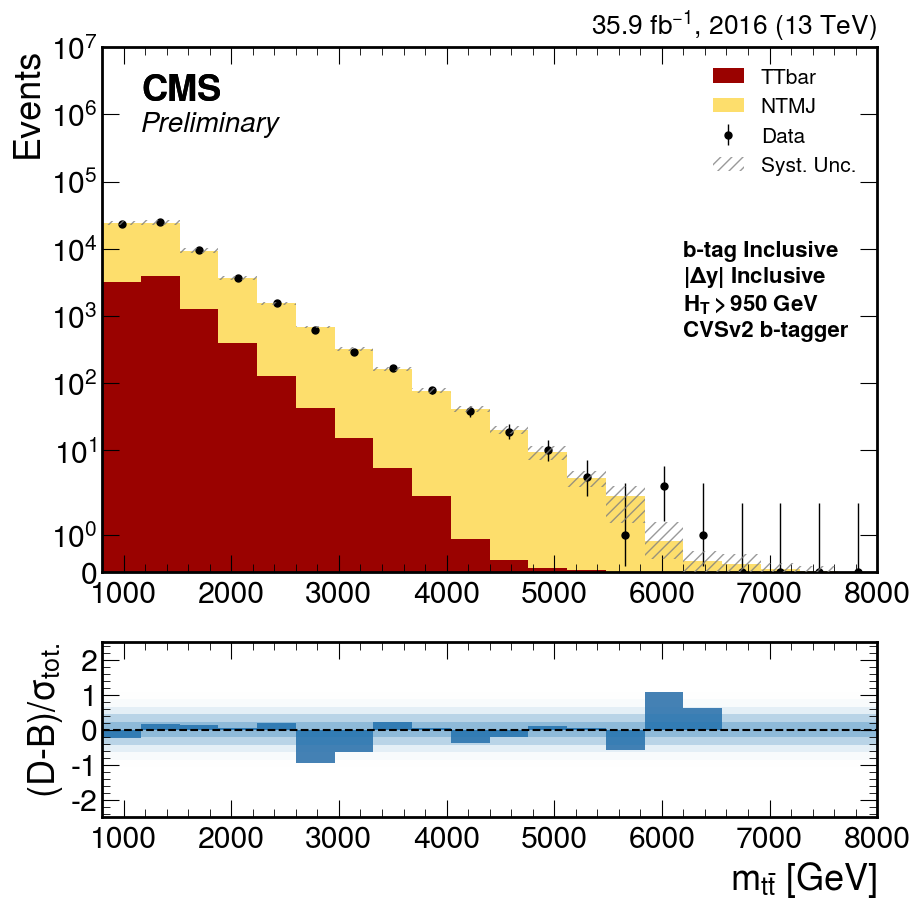

In [29]:
variable = 'ttbarmass'  # Change this at will
signal = 'ZPrime30'
useSignal = False
usePull = True
Linear = False
# removeBkg = False
linearStr = ''
sigstr = ''
SaveFileName = f'../data/BkgEstEventCounts_Inc{oldHTstr}.txt'

# -- prepare to overwrite event-count txt -- #
file_to_delete = open(SaveFileName,'w')
file_to_delete.close()

if Linear:
    linearStr = '_LINEAR'
histDict = {}

dirname = 'closureTest'
if variable != 'ttbarmass':
    dirname = 'kinematics'
if useSignal:
    sigstr = '_with_' + signal
    
    
for IOV in IOVs:

    if 'Full' in IOV:
        histDict = UseFullIOV(variable, signal)
        SystemUnc = getSystUncFull(histDict, variable, signal, systematics, '', False)
    elif '2016all' in IOV:
        histDict = Use2016allIOV(variable, signal)
        SystemUnc = getSystUnc2016all(histDict, variable, signal, systematics, '', False)
    else:
        histDict = UseIOV(variable, signal, IOV)
        SystemUnc = getSystUnc(histDict, variable, signal, systematics, IOV, '', False)
        
    if Linear:
        text = f'Preliminary'
    else:
        text = f'Preliminary\n'

    plotBackgroundEstimate(histDict, SystemUnc, text, SaveFileName, True, '', signal, variable, Linear, usePull, useSignal)
        
    if usePull:
        savefilename = f'images/png/kinematics/{IOV}/{variable}{sigstr}_Inclusive{linearStr}.png'
    else:
        savefilename = f'images/png/{dirname}/{IOV}/{variable}{sigstr}_Inclusive{linearStr}.png'

    print(savefilename)
#     plt.savefig(savefilename)
#     plt.savefig(savefilename.replace('png', 'pdf'))

    plt.show()

## plot background estimate (by category)

/tmp/ipykernel_5532/3672959946.py:8: RuntimeWarning: divide by zero encountered in divide
  mistag_data = np.where(HistDict['pretag'].values()>0., HistDict['ntmj_fixed'].values() / HistDict['pretag'].values(), 0.)
/tmp/ipykernel_5532/3672959946.py:8: RuntimeWarning: invalid value encountered in divide
  mistag_data = np.where(HistDict['pretag'].values()>0., HistDict['ntmj_fixed'].values() / HistDict['pretag'].values(), 0.)
/tmp/ipykernel_5532/3672959946.py:12: RuntimeWarning: divide by zero encountered in divide
  term1 = np.where(HistDict['pretag'].values()>0., 1. / HistDict['pretag'].values(), 0.)
/tmp/ipykernel_5532/3672959946.py:13: RuntimeWarning: divide by zero encountered in divide
  term2 = np.where( (Ndenom*mistag_data)>0., (np.ones(len(mistag_data))-mistag_data)/(Ndenom*mistag_data), 0. )
/tmp/ipykernel_5532/3672959946.py:19: RuntimeWarning: invalid value encountered in divide
  mmPercentErr = np.where( mmTerm2>0., mmTerm1/mmTerm2, 0. ) # Calculated percent error of the diffe

qcdClosure Percent Difference =  [-3.00049845e-02 -2.74890617e-02  4.55257411e-02  2.33452009e-02
 -2.66510113e-02 -3.42546702e-03 -1.18282541e-02 -4.56326728e-02
 -3.85355500e-02  3.27099259e-07 -4.43936673e-02 -7.51909551e-02
 -7.09293961e-02  6.34746996e-02  9.79458426e-02  1.17617388e-01
  3.36787032e-02 -3.23795498e-02  1.69629677e-01 -1.14374887e-01]
Mass Mod Percent Difference =  [ 1.62547196e-03 -1.75198190e-03  3.45134420e-03  1.61442446e-02
  1.67552287e-03  6.17554271e-02 -1.14990312e-01 -3.42592765e-02
 -5.22542908e-02  2.26904320e-01 -5.09821416e-03 -3.12365740e-01
  3.90554386e-01 -6.82193008e-01 -2.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00]
mistagErr =  [64.30803254 42.21723165 16.16157948  7.48814275  4.10932186  2.39005469
  1.74456528  0.93874623  0.66609604  0.55053109  0.37696566  0.37323267
  0.16394077  0.25354791  0.          0.          0.          0.
  0.          0.        ]
massmodErr =  [ 2.19915285e+01 -1.

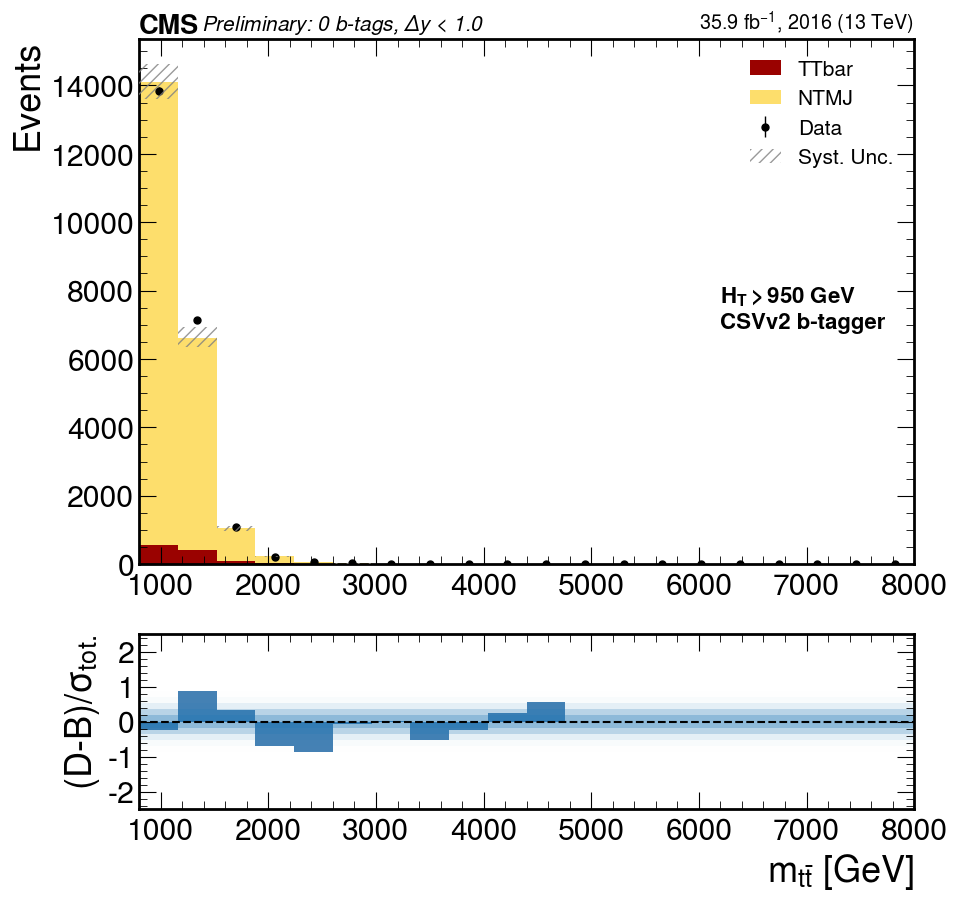

/tmp/ipykernel_5532/3672959946.py:8: RuntimeWarning: invalid value encountered in divide
  mistag_data = np.where(HistDict['pretag'].values()>0., HistDict['ntmj_fixed'].values() / HistDict['pretag'].values(), 0.)
/tmp/ipykernel_5532/3672959946.py:12: RuntimeWarning: divide by zero encountered in divide
  term1 = np.where(HistDict['pretag'].values()>0., 1. / HistDict['pretag'].values(), 0.)
/tmp/ipykernel_5532/3672959946.py:13: RuntimeWarning: divide by zero encountered in divide
  term2 = np.where( (Ndenom*mistag_data)>0., (np.ones(len(mistag_data))-mistag_data)/(Ndenom*mistag_data), 0. )
/tmp/ipykernel_5532/3672959946.py:19: RuntimeWarning: invalid value encountered in divide
  mmPercentErr = np.where( mmTerm2>0., mmTerm1/mmTerm2, 0. ) # Calculated percent error of the difference
/opt/conda/lib/python3.8/site-packages/boost_histogram/_internal/view.py:190: RuntimeWarning: invalid value encountered in divide
  ufunc(
/opt/conda/lib/python3.8/site-packages/boost_histogram/_internal/view

qcdClosure Percent Difference =  [ 0.14604242 -0.07721277 -0.06969674 -0.02403223  0.00081966 -0.01508749
 -0.02373892 -0.059091    0.01653902 -0.05482184 -0.06496285  0.07046175
  0.03846118 -0.09233182  0.05364419  0.30304918 -0.00306501 -0.23236045
 -0.11609748  0.31911762]
Mass Mod Percent Difference =  [ 5.29991051e-03 -3.63682115e-04  1.91594000e-03 -6.39003343e-03
  7.84169704e-04 -4.08756989e-03  5.53822055e-03  2.14671972e-03
  2.77328371e-02 -9.00137952e-04 -3.77773196e-03  9.82051387e-02
 -4.77532948e-02  1.65790190e-01  2.63872167e-01  3.96054806e-01
 -6.61280516e-01  0.00000000e+00  6.66666667e-01  0.00000000e+00]
mistagErr =  [26.22881025 52.94059396 38.04197357 24.87880467 16.3210181  11.04956577
  7.6673692   5.57540122  3.81867229  2.81770308  1.99648637  1.53024169
  0.79618996  0.54209303  0.35217539  0.274752    0.23426071  0.
  0.16935167  0.        ]
massmodErr =  [ 11.64124776  -3.38137724   9.72922579 -14.29851663   0.7782816
  -1.87454014   1.21701427   0.24192

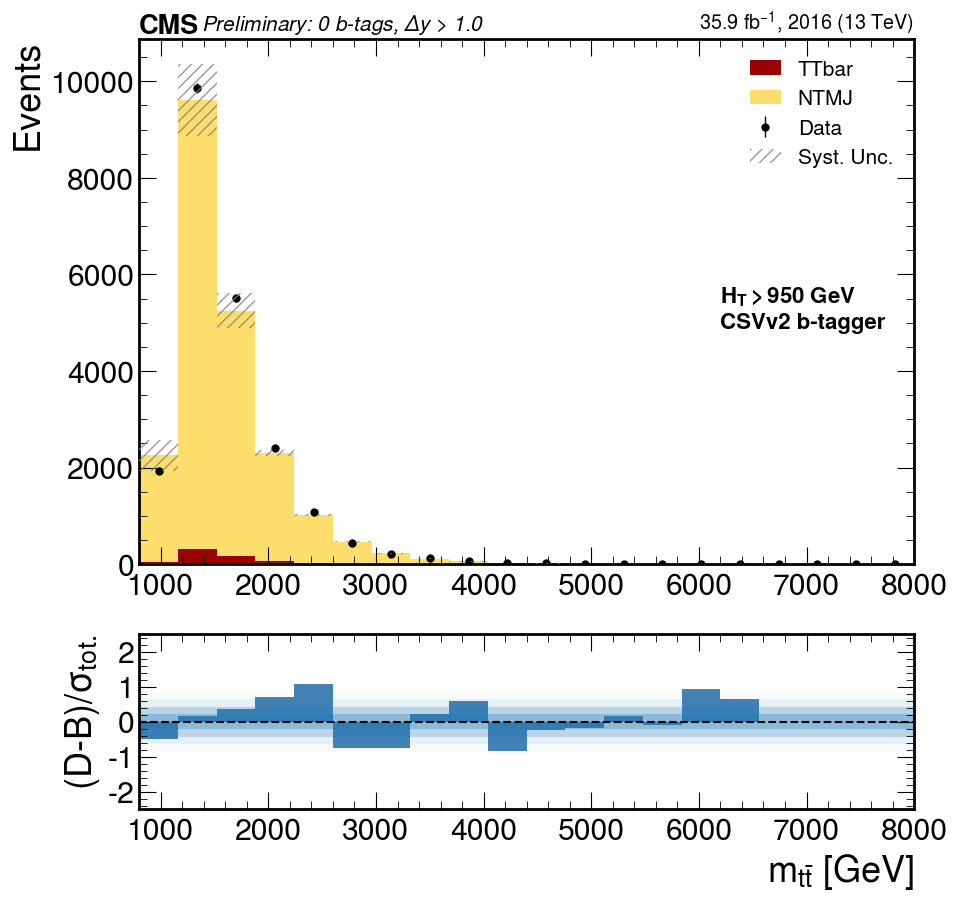

/tmp/ipykernel_5532/3672959946.py:8: RuntimeWarning: divide by zero encountered in divide
  mistag_data = np.where(HistDict['pretag'].values()>0., HistDict['ntmj_fixed'].values() / HistDict['pretag'].values(), 0.)
/tmp/ipykernel_5532/3672959946.py:8: RuntimeWarning: invalid value encountered in divide
  mistag_data = np.where(HistDict['pretag'].values()>0., HistDict['ntmj_fixed'].values() / HistDict['pretag'].values(), 0.)
/tmp/ipykernel_5532/3672959946.py:12: RuntimeWarning: divide by zero encountered in divide
  term1 = np.where(HistDict['pretag'].values()>0., 1. / HistDict['pretag'].values(), 0.)
/tmp/ipykernel_5532/3672959946.py:13: RuntimeWarning: divide by zero encountered in divide
  term2 = np.where( (Ndenom*mistag_data)>0., (np.ones(len(mistag_data))-mistag_data)/(Ndenom*mistag_data), 0. )
/tmp/ipykernel_5532/3672959946.py:19: RuntimeWarning: invalid value encountered in divide
  mmPercentErr = np.where( mmTerm2>0., mmTerm1/mmTerm2, 0. ) # Calculated percent error of the diffe

qcdClosure Percent Difference =  [ 0.16060092  0.03243501  0.03491808 -0.00989905  0.01130841  0.00269863
 -0.03464618 -0.04952435 -0.03759853  0.00806082  0.06292829 -0.06615674
  0.08932553  0.06910651 -0.15237981 -0.16502671  0.00844053  0.14424774
  0.07747122 -0.03639892]
Mass Mod Percent Difference =  [-1.30065986e-02 -5.06782564e-03 -3.18785644e-04 -2.82973364e-02
 -1.16253480e-01 -7.47527522e-02 -1.27005988e-01 -1.12261091e-01
  5.21122681e-01  4.30665207e-01 -1.00377725e+00  7.10860049e-01
 -1.03175621e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00]
mistagErr =  [37.42705356 25.24381229  9.87378139  4.71403974  2.71659637  1.64686942
  1.03374334  0.81461638  0.29210555  0.19776154  0.37964984  0.29366312
  0.2123217  -0.          0.          0.          0.          0.
  0.          0.        ]
massmodErr =  [-5.16032241e+01 -9.60175905e+00 -9.73079157e-02 -1.93937914e+00
 -2.45333367e+00 -5.54798339e-01 -3.

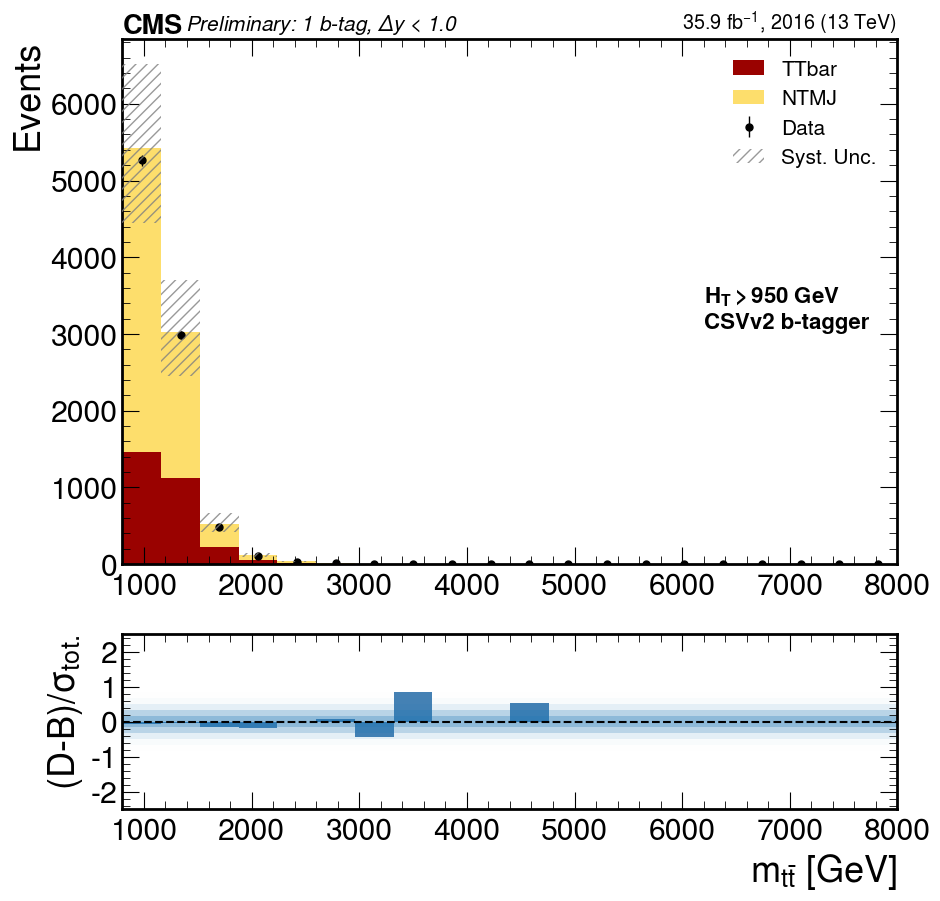

/tmp/ipykernel_5532/3672959946.py:8: RuntimeWarning: divide by zero encountered in divide
  mistag_data = np.where(HistDict['pretag'].values()>0., HistDict['ntmj_fixed'].values() / HistDict['pretag'].values(), 0.)
/tmp/ipykernel_5532/3672959946.py:8: RuntimeWarning: invalid value encountered in divide
  mistag_data = np.where(HistDict['pretag'].values()>0., HistDict['ntmj_fixed'].values() / HistDict['pretag'].values(), 0.)
/tmp/ipykernel_5532/3672959946.py:12: RuntimeWarning: divide by zero encountered in divide
  term1 = np.where(HistDict['pretag'].values()>0., 1. / HistDict['pretag'].values(), 0.)
/tmp/ipykernel_5532/3672959946.py:13: RuntimeWarning: divide by zero encountered in divide
  term2 = np.where( (Ndenom*mistag_data)>0., (np.ones(len(mistag_data))-mistag_data)/(Ndenom*mistag_data), 0. )
/tmp/ipykernel_5532/3672959946.py:19: RuntimeWarning: invalid value encountered in divide
  mmPercentErr = np.where( mmTerm2>0., mmTerm1/mmTerm2, 0. ) # Calculated percent error of the diffe

qcdClosure Percent Difference =  [-5.61925661e-01 -1.40111691e-01 -1.01704254e-01  1.95295627e-02
 -1.98548853e-02 -4.93813378e-02 -3.59730372e-02  2.15879403e-02
 -3.80039273e-03  3.22690067e-02  4.25613177e-02 -5.79439390e-02
  2.11334923e-01  1.03732961e-01 -3.98718914e-04 -6.62599121e-02
  9.60729494e-02  7.39280814e-01  1.51942581e-01 -3.96098448e-01]
Mass Mod Percent Difference =  [-1.18424317e-02  8.39475515e-04 -2.30598109e-03  9.02887348e-03
  3.34722008e-03 -1.10376743e-02 -2.70223768e-02 -5.65255679e-02
  5.58081375e-02 -1.26640033e-01  1.78215055e-01  5.73058338e-02
  9.63938591e-02 -2.38312624e-02  2.43392838e-03 -2.00000000e+00
  6.55515070e-01 -6.66666667e-01  0.00000000e+00  0.00000000e+00]
mistagErr =  [14.95034155 30.67362922 22.46012213 14.56801841  9.67878788  6.58566564
  4.41057338  3.38009934  2.39557677  1.82943859  1.38122658  0.91130107
  0.60572723  0.54981733  0.31796173  0.          0.11399802  0.30266943
  0.          0.        ]
massmodErr =  [-7.39802422

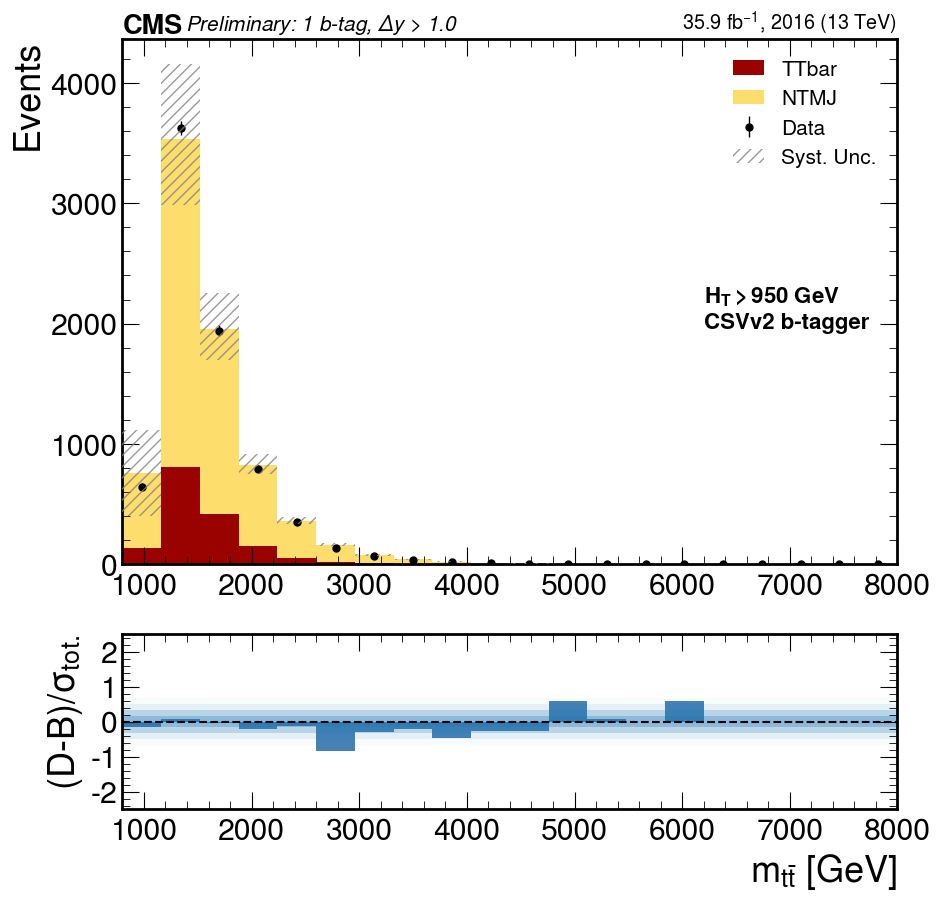

/tmp/ipykernel_5532/3672959946.py:8: RuntimeWarning: divide by zero encountered in divide
  mistag_data = np.where(HistDict['pretag'].values()>0., HistDict['ntmj_fixed'].values() / HistDict['pretag'].values(), 0.)
/tmp/ipykernel_5532/3672959946.py:8: RuntimeWarning: invalid value encountered in divide
  mistag_data = np.where(HistDict['pretag'].values()>0., HistDict['ntmj_fixed'].values() / HistDict['pretag'].values(), 0.)
/tmp/ipykernel_5532/3672959946.py:12: RuntimeWarning: divide by zero encountered in divide
  term1 = np.where(HistDict['pretag'].values()>0., 1. / HistDict['pretag'].values(), 0.)
/tmp/ipykernel_5532/3672959946.py:13: RuntimeWarning: divide by zero encountered in divide
  term2 = np.where( (Ndenom*mistag_data)>0., (np.ones(len(mistag_data))-mistag_data)/(Ndenom*mistag_data), 0. )
/tmp/ipykernel_5532/3672959946.py:19: RuntimeWarning: invalid value encountered in divide
  mmPercentErr = np.where( mmTerm2>0., mmTerm1/mmTerm2, 0. ) # Calculated percent error of the diffe

qcdClosure Percent Difference =  [ 1.2572055  -0.05632248  0.10257728 -0.01269076  0.03192816  0.22418442
 -0.11379436 -0.11645742  0.08011525 -0.21879205 -0.1998545   0.11383562
 -0.02334266 -0.27916472  0.30062703 -0.75493836  0.61622329  0.38129915
  0.46353254  0.33852041]
Mass Mod Percent Difference =  [-0.20842317 -0.23170305 -0.22757964 -0.23444857 -0.02301811  0.20844581
 -0.06728714 -0.13241012  3.04742541 -1.98861851  1.98462566  0.
  0.          0.          0.          0.          0.          0.
  0.          0.        ]
mistagErr =  [ 1.17630703e+01  8.08062093e+00  3.43656584e+00  1.48082718e+00
  8.60392337e-01  3.34023956e-01  3.30906204e-01  6.60175760e-02
 -6.32786798e-03  6.46044099e-01  1.03016370e-02 -0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00]
massmodErr =  [-5.60509905e+01 -3.14251869e+01 -6.07204692e+00 -1.24705651e+00
 -4.27873538e-02  8.33193367e-02 -2.04308616

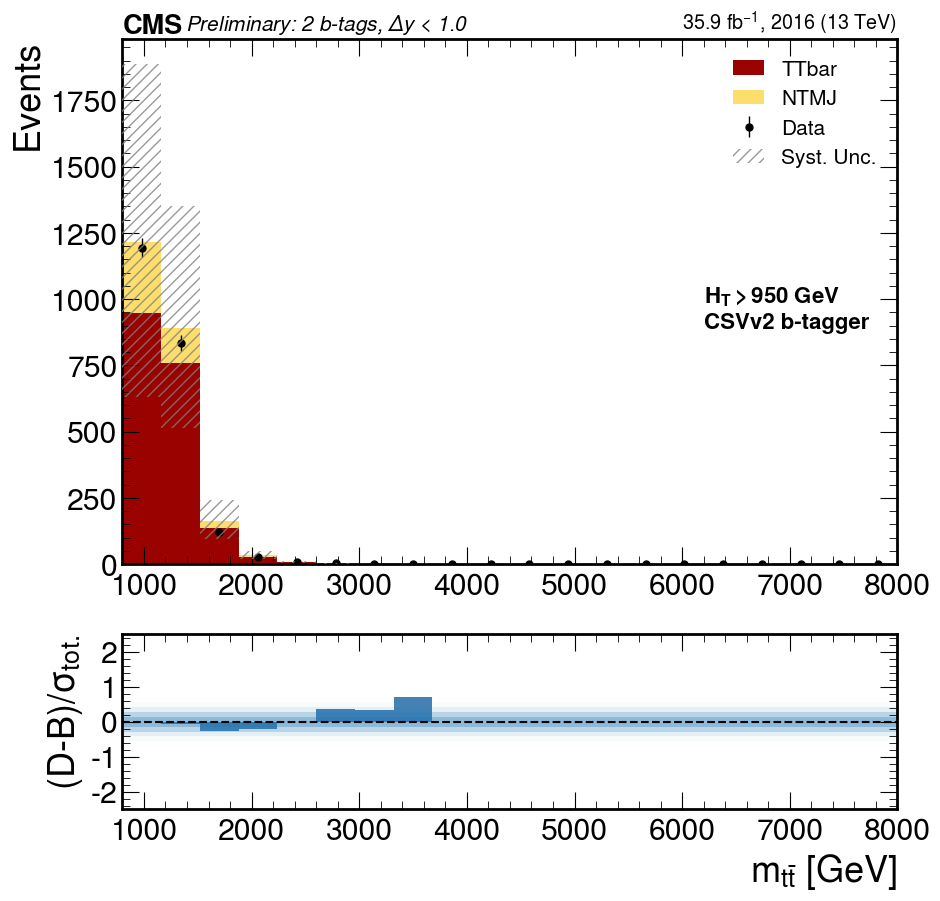

/tmp/ipykernel_5532/3672959946.py:8: RuntimeWarning: invalid value encountered in divide
  mistag_data = np.where(HistDict['pretag'].values()>0., HistDict['ntmj_fixed'].values() / HistDict['pretag'].values(), 0.)
/tmp/ipykernel_5532/3672959946.py:12: RuntimeWarning: divide by zero encountered in divide
  term1 = np.where(HistDict['pretag'].values()>0., 1. / HistDict['pretag'].values(), 0.)
/tmp/ipykernel_5532/3672959946.py:13: RuntimeWarning: divide by zero encountered in divide
  term2 = np.where( (Ndenom*mistag_data)>0., (np.ones(len(mistag_data))-mistag_data)/(Ndenom*mistag_data), 0. )
/tmp/ipykernel_5532/3672959946.py:19: RuntimeWarning: invalid value encountered in divide
  mmPercentErr = np.where( mmTerm2>0., mmTerm1/mmTerm2, 0. ) # Calculated percent error of the difference
/opt/conda/lib/python3.8/site-packages/boost_histogram/_internal/view.py:190: RuntimeWarning: invalid value encountered in divide
  ufunc(
/opt/conda/lib/python3.8/site-packages/boost_histogram/_internal/view

qcdClosure Percent Difference =  [-1.44521399  0.14150965  0.12052569  0.0403439  -0.03486761 -0.19801561
  0.30163685 -0.18795685  0.14478134 -0.21362722  0.2940623  -0.14959594
  0.46281341  0.33253691 -0.33910084  0.3230409  -0.21693484  1.10355338
  0.37465673 -0.47046634]
Mass Mod Percent Difference =  [-0.16191881 -0.11325821 -0.07490616 -0.05659735  0.00853654 -0.07345072
 -0.09672059  0.02820666  0.19706786 -0.14599795  0.31260093  2.07000395
 -0.59296186  0.          0.          0.          0.          0.
  0.          0.        ]
mistagErr =  [ 4.43178020e+00  9.28426676e+00  6.90305369e+00  4.48425030e+00
  2.79987491e+00  1.94994072e+00  1.32514399e+00  9.91309572e-01
  8.34770448e-01  7.16203799e-01  3.46551210e-01 -3.88094080e-03
  2.35388191e-01  1.58347379e-01  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00]
massmodErr =  [-6.74550973e+00 -2.14705106e+01 -8.74634671e+00 -3.06719704e+00
  2.12894434e-01 -8.84592679e-01 -5.

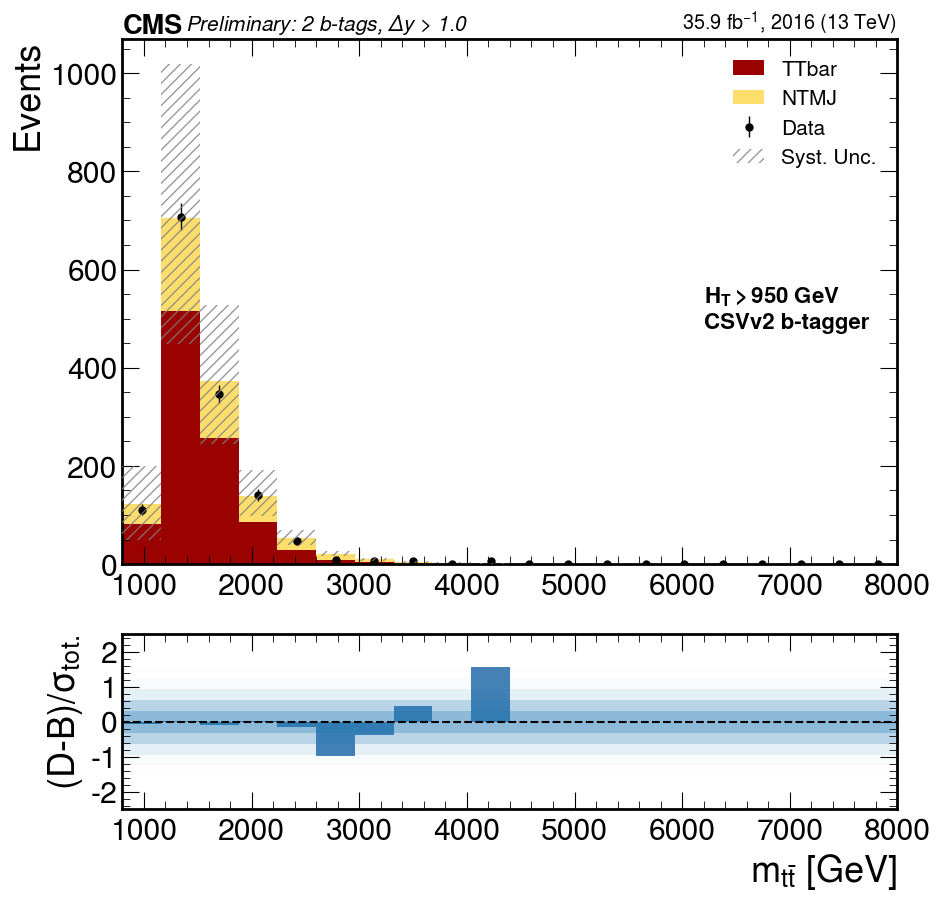

In [31]:
variable = 'ttbarmass'  # Change this at will
signal = 'ZPrime30'
useSignal = False
usePull = True
Linear = True
linearStr = ''
sigstr = ''

SaveFileName = f'../data/BkgEstEventCounts_Categories{oldHTstr}.txt'

# -- prepare to overwrite event-count txt -- #
file_to_delete = open(SaveFileName,'w')
file_to_delete.close()

if Linear:
    linearStr = '_LINEAR'
histDict = {}

dirname = 'closureTest'
if variable != 'ttbarmass':
    dirname = 'kinematics'
if useSignal:
    sigstr = '_with_' + signal
    
for IOV in IOVs:
    
    for cat in ['0bcen', '0bfwd', '1bcen', '1bfwd', '2bcen', '2bfwd']:
    # for cat in ['2bcen', '2bfwd']:

        if 'Full' in IOV:
            histDict = UseFullIOV(variable, signal, cat)
            SystemUnc = getSystUncFull(histDict, variable, signal, systematics, cat, False)
#             SystemUncContam = getSystUncFull(histDict, variable, signal, systematics, cat, True)
        elif '2016all' in IOV:
            histDict = Use2016allIOV(variable, signal, cat)
            SystemUnc = getSystUnc2016all(histDict, variable, signal, systematics, cat, False)
#             SystemUncContam = getSystUnc2016all(histDict, variable, signal, systematics, cat, True)
        else:
            histDict = UseIOV(variable, signal, cat)
            SystemUnc = getSystUnc(histDict, variable, signal, systematics, cat, False)
#             SystemUncContam = getSystUnc(histDict, variable, signal, systematics, cat, True)
            
        dytext = ''
        if 'cen' in cat:
            dytext = r'$\Delta y$ < 1.0'
        elif 'fwd' in cat:
            dytext = r'$\Delta y$ > 1.0'

        btext = ''
        if '0b' in cat:
            btext = '0 b-tags'
        elif '1b' in cat:
            btext = '1 b-tag'
        elif '2b' in cat:
            btext = '2 b-tags'

        if Linear:
            text = f'Preliminary:    {btext}, {dytext}'
        else:
            text = f'Preliminary\n{btext}, {dytext} \n'
            

        plotBackgroundEstimate(histDict, SystemUnc, text, SaveFileName, False, cat, signal, variable, Linear, usePull, useSignal)

        if usePull:
            savefilename = f'images/png/kinematics/{IOV}/{variable}{sigstr}_{cat}{linearStr}.png'
        else:
            savefilename = f'images/png/{dirname}/{IOV}/{variable}{sigstr}_{cat}{linearStr}.png'

        print(savefilename)
#         plt.savefig(savefilename)
#         plt.savefig(savefilename.replace('png', 'pdf'))

        plt.show()

# Comparison without Mass Modification (Inclusive)

In [ ]:
# variable = 'ttbarmass'  # Change this at will
# signal = 'ZPrime30'
# useSignal = False
# usePull = True
# Linear = True
# # removeBkg = False
# linearStr = ''
# sigstr = ''
# if Linear:
#     linearStr = '_LINEAR'
# histDict = {}

# dirname = 'closureTest'
# if variable != 'ttbarmass':
#     dirname = 'kinematics'
# if useSignal:
#     sigstr = '_with_' + signal
    
    
# for IOV in IOVs:

#     if 'Full' in IOV:
#         histDict = UseFullIOV(variable, signal)
#     elif '2016all' in IOV:
#         histDict = Use2016allIOV(variable, signal)
#         SystemUnc = getSystUnc2016all(histDict, variable, signal, systematics, '', False)
#     else:
#         histDict = UseIOV(variable, signal)

#     if Linear:
#         text = f'Preliminary'
#     else:
#         text = f'Preliminary\n'

#     plotBackgroundEstimateComparison(histDict, SystemUnc, text, True, signal, variable, Linear, usePull, useSignal)
        
#     if usePull:
#         savefilename = f'images/png/kinematics/{IOV}/{variable}{sigstr}_Inclusive{linearStr}.png'
#     else:
#         savefilename = f'images/png/{dirname}/{IOV}/{variable}{sigstr}_Inclusive{linearStr}.png'
        

#     print(savefilename)
# #     plt.savefig(savefilename)
# #     plt.savefig(savefilename.replace('png', 'pdf'))

#     plt.show()

# Comparison without Mass Modification (Categories)

In [ ]:
# variable = 'ttbarmass'  # Change this at will
# signal = 'ZPrime1'
# useSignal = False
# usePull = True
# Linear = True
# linearStr = ''
# sigstr = ''
# if Linear:
#     linearStr = '_LINEAR'
# histDict = {}

# dirname = 'closureTest'
# if variable != 'ttbarmass':
#     dirname = 'kinematics'
# if useSignal:
#     sigstr = '_with_' + signal
    
# for IOV in IOVs:
    
#     for cat in ['0bcen', '0bfwd', '1bcen', '1bfwd', '2bcen', '2bfwd']:

#         if 'Full' in IOV:
#             histDict = UseFullIOV(variable, signal, cat)
#         elif '2016all' in IOV:
#             histDict = Use2016allIOV(variable, signal, cat)
#             SystemUnc = getSystUnc2016all(histDict, variable, signal, systematics, cat, False)
#         else:
#             histDict = UseIOV(variable, signal, cat)
            
#         dytext = ''
#         if 'cen' in cat:
#             dytext = r'$\Delta y$ < 1.0'
#         elif 'fwd' in cat:
#             dytext = r'$\Delta y$ > 1.0'

#         btext = ''
#         if '0b' in cat:
#             btext = '0 b-tags'
#         elif '1b' in cat:
#             btext = '1 b-tag'
#         elif '2b' in cat:
#             btext = '2 b-tags'

#         if Linear:
#             text = f'Preliminary:    {btext}, {dytext}'
#         else:
#             text = f'Preliminary\n{btext}, {dytext} \n'

#         plotBackgroundEstimateComparison(histDict, SystemUnc, text, False, signal, variable, Linear, usePull, useSignal)

#         if usePull:
#             savefilename = f'images/png/kinematics/{IOV}/{variable}{sigstr}_{cat}{linearStr}.png'
#         else:
#             savefilename = f'images/png/{dirname}/{IOV}/{variable}{sigstr}_{cat}{linearStr}.png'

#         print(savefilename)
# #         plt.savefig(savefilename)
# #         plt.savefig(savefilename.replace('png', 'pdf'))

#         plt.show()

In [ ]:
Signals = {
    'ZPrime1' : ['1000', '1200', '1400', '1600', '1800', '2000', '2500', '3000', '3500', '4000', '4500'],
    'ZPrime10': ['1000', '1200', '1400', '1600', '1800', '2000', '2500', '3000', '3500', '4000', '4500', '5000'],
    'ZPrime30': ['1000', '1200', '1400', '1600', '1800', '2000', '2500', '3000', '3500', '4000', '4500', '5000'],
    'ZPrimeDM': ['1000', '1500', '2000', '2500', '3000', '3500', '4000', '4500', '5000'],
    'RSGluon':  ['1000', '1500', '2000', '2500', '3000', '3500', '4000', '4500', '5000']
}

signal = 'ZPrime30'

IOV = '2016all'

cats = ['0bcen', '0bfwd', '1bcen', '1bfwd', '2bcen', '2bfwd']
cat_labels = ['cen0b', 'fwd0b', 'cen1b', 'fwd1b', 'cen2b', 'fwd2b']

# systematics = [
#         'jes',
#         'jer',
#         'pileup',
#         'pdf',
#         'q2',
#         'btag',
#         'toptagsf',
#         'toptagxs',
#         'lumi',
#         'prefiring'
#     ]
syst_labels = ['nominal']
for s in systematics:
    if not 'nominal' in s:
        syst_labels.append(s+'Down')
        syst_labels.append(s+'Up')
        
# print(syst_labels)

savefileheader = '../outputs/combine/TTbarAllHad{}_'.format(IOV.replace('20', '').replace('all',''))
# print(savefileheader)

froot = uproot.recreate(savefileheader+'CombineRoot_Cat_950_oldBTag.root')

variable = 'ttbarmass'



# for cat, catname in zip(cats, cat_labels):
#     signal_cat = label_to_int_dict['2t'+cat]
#     pretag_cat = label_to_int_dict['pret'+cat]
#     httbar_trial = getHist(variable, 'TTbar', False, '2017', sum_axes=[], integrate_axes={'anacat':signal_cat})
#     print(httbar_trial)



# for IOV in IOVs:

for cat, catname in zip(cats, cat_labels):

    signal_cat = label_to_int_dict['2t'+cat]
    pretag_cat = label_to_int_dict['pret'+cat]

    hsignal = {}
    hsignal['ZPrime1'] = {}
    hsignal['ZPrime10'] = {}
    hsignal['ZPrime30'] = {}
    hsignal['ZPrimeDM'] = {}
    hsignal['RSGluon'] = {}

    HistDict = Use2016allIOV(variable, signal, cat)
    Hbkg = HistDict['ntmj'] + HistDict['ttbar']
    Hbkg_fixed = HistDict['ntmj_fixed'] + HistDict['ttbar']
    Ndenom = HistDict['antitag_data'].values() - HistDict['antitag_ttbar'].values()
    mistag_data = np.where(HistDict['pretag'].values()>0., HistDict['ntmj_fixed'].values() / HistDict['pretag'].values(), 0.)
    term1 = np.where(HistDict['pretag'].values()>0., 1. / HistDict['pretag'].values(), 0.)
    term2 = np.where( (Ndenom*mistag_data)>0., (np.ones(len(mistag_data))-mistag_data)/(Ndenom*mistag_data), 0. ) 
    mistagErrProp =  HistDict['ntmj_fixed']*np.sqrt( term1 + term2 )# 1 + 2 = mistag error & stat. error of NTMJ
    
    mmTerm1 = (HistDict['ntmj_fixed_noMM'].values() - HistDict['ntmj_fixed'].values()) # "source" of Mass Mod error
    mmTerm2 = (HistDict['ntmj_fixed_noMM'].values() + HistDict['ntmj_fixed'].values()) / 2.
    mmPercentErr = np.where( mmTerm2>0., mmTerm1/mmTerm2, 0. ) # Calculated percent error of the difference
    mmErrProp = HistDict['ntmj_fixed']*np.abs(mmPercentErr) # Mass Mod error
    
    qcdTerm1 = (HistDict['QCDbkgest'].values() - HistDict['QCDsignal'].values()) # "source" of QCD closure error
    qcdTerm2 = (HistDict['QCDbkgest'].values() + HistDict['QCDsignal'].values()) / 2.
    qcdPercentErr = np.where((qcdTerm2 > 10**(-4)), qcdTerm1/qcdTerm2, 0.) # Calculated percent error of the difference
    qcdErrProp = HistDict['ntmj_fixed']*np.abs(qcdPercentErr) #QCD closure error
    # qcdErrProp = np.zeros(len(qcdTerm1)) # temporarily turn off QCD ERROR for testing

    froot["bkgest_"+catname+'_mistagUp'] = HistDict['ntmj_fixed'] + mistagErrProp
    froot["bkgest_"+catname+'_mistagDown'] = HistDict['ntmj_fixed'] + -1.0*mistagErrProp

    froot["bkgest_"+catname+'_massmodUp'] = HistDict['ntmj_fixed'] + mmErrProp
    froot["bkgest_"+catname+'_massmodDown'] = HistDict['ntmj_fixed'] + -1.0*mmErrProp

    froot["bkgest_"+catname+'_qcdclosureUp'] = HistDict['ntmj_fixed'] + qcdErrProp
    froot["bkgest_"+catname+'_qcdclosureDown'] = HistDict['ntmj_fixed'] + -1.0*qcdErrProp

    for syst in syst_labels:

        if 'Full' in IOV:

            catsystString = catname+'_'+syst

            httbar_apv        = getHist(variable, 'TTbar', False, '2016APV', sum_axes=[], integrate_axes={'anacat':signal_cat, 'systematic':syst})
            hcontam_apv       = getHist(variable, 'TTbar', True, '2016APV', sum_axes=[], integrate_axes={'anacat':pretag_cat, 'systematic':syst})
            httbar_noapv      = getHist(variable, 'TTbar', False, '2016', sum_axes=[], integrate_axes={'anacat':signal_cat, 'systematic':syst})
            hcontam_noapv     = getHist(variable, 'TTbar', True, '2016', sum_axes=[], integrate_axes={'anacat':pretag_cat, 'systematic':syst})
            httbar_17      = getHist(variable, 'TTbar', False, '2017', sum_axes=[], integrate_axes={'anacat':signal_cat, 'systematic':syst})
            hcontam_17     = getHist(variable, 'TTbar', True, '2017', sum_axes=[], integrate_axes={'anacat':pretag_cat, 'systematic':syst})
            httbar_18      = getHist(variable, 'TTbar', False, '2018', sum_axes=[], integrate_axes={'anacat':signal_cat, 'systematic':syst})
            hcontam_18     = getHist(variable, 'TTbar', True, '2018', sum_axes=[], integrate_axes={'anacat':pretag_cat, 'systematic':syst})

            print('loading signals...')
            for sig in Signals.keys():
                for mass in Signals[sig]:
                    hsignal_apv   = getHist(variable, sig, False, '2016APV', sum_axes=[], integrate_axes={'anacat':signal_cat, 'systematic':syst}, masspoint=mass)
                    hsignal_noapv = getHist(variable, sig, False, '2016', sum_axes=[], integrate_axes={'anacat':signal_cat, 'systematic':syst}, masspoint=mass)
                    hsignal_17 = getHist(variable, sig, False, '2017', sum_axes=[], integrate_axes={'anacat':signal_cat, 'systematic':syst}, masspoint=mass)
                    hsignal_18 = getHist(variable, sig, False, '2018', sum_axes=[], integrate_axes={'anacat':signal_cat, 'systematic':syst}, masspoint=mass)
                    hsignal[sig][mass] = hsignal_apv + hsignal_noapv + hsignal_17 + hsignal_18

            httbar  = httbar_apv + httbar_noapv + httbar_17 + httbar_18
            hcontam = hcontam_apv + hcontam_noapv + hcontam_17 + hcontam_18

            print('filling root files...')
            if 'nominal' in syst:
                syst = ''
                catsystString = catname+syst
                hntmj_apv   = getHist(variable, 'JetHT', True, '2016APV',   sum_axes=[], integrate_axes={'anacat':pretag_cat, 'systematic':'nominal'})
                hdata_apv   = getHist(variable, 'JetHT', False, '2016APV',  sum_axes=[], integrate_axes={'anacat':signal_cat, 'systematic':'nominal'})
                hntmj_noapv = getHist(variable, 'JetHT', True, '2016',   sum_axes=[], integrate_axes={'anacat':pretag_cat, 'systematic':'nominal'})
                hdata_noapv = getHist(variable, 'JetHT', False, '2016',  sum_axes=[], integrate_axes={'anacat':signal_cat, 'systematic':'nominal'})
                hntmj_17 = getHist(variable, 'JetHT', True, '2017',   sum_axes=[], integrate_axes={'anacat':pretag_cat, 'systematic':'nominal'})
                hdata_17 = getHist(variable, 'JetHT', False, '2017',  sum_axes=[], integrate_axes={'anacat':signal_cat, 'systematic':'nominal'})
                hntmj_18 = getHist(variable, 'JetHT', True, '2018',   sum_axes=[], integrate_axes={'anacat':pretag_cat, 'systematic':'nominal'})
                hdata_18 = getHist(variable, 'JetHT', False, '2018',  sum_axes=[], integrate_axes={'anacat':signal_cat, 'systematic':'nominal'})

                hntmj = hntmj_apv + hntmj_noapv + hntmj_17 + hntmj_18
                hdata = hdata_apv + hdata_noapv + hdata_17 + hdata_18
                hntmj_fixed = hntmj + -1*hcontam
                print('data_obs_'+catsystString+'\nbkgest_'+catsystString)
                froot["data_obs_"+catsystString] = hdata
                froot["bkgest_"+catsystString] = hntmj_fixed

            print('TTbar_'+catsystString)
            froot["TTbar_"+catsystString] = httbar


            for sig in Signals.keys():

                if 'RSGluon' not in sig:
                    if sig != 'ZPrime1': # ZPrime10, 30 and DM
                        [print(sig[:-2]+mass+'_'+sig[-2:]+'_'+catsystString) for mass in Signals[sig]]
                        for mass in Signals[sig]:
                            froot[sig[:-2]+mass+'_'+sig[-2:]+'_'+catsystString] = hsignal[sig][mass]
                    else: # ZPrime1
                        [print(sig[:-1]+mass+'_'+sig[-1:]+'_'+catsystString) for mass in Signals[sig]]
                        for mass in Signals[sig]:
                            froot[sig[:-1]+mass+'_'+sig[-1:]+'_'+catsystString] = hsignal[sig][mass]
                else: # RSGluon
                    [print(sig+mass+'_'+catsystString) for mass in Signals[sig]]
                    for mass in Signals[sig]:
                        froot[sig+mass+'_'+catsystString] = hsignal[sig][mass]

            # -- quick nominal plot to see how hists look -- #
#                 if syst == '':
            dytext = ''
            if 'cen' in cat:
                dytext = r'$\Delta y$ < 1.0'
            elif 'fwd' in cat:
                dytext = r'$\Delta y$ > 1.0'

            btext = ''
            if '0b' in cat:
                btext = '0 b-tags'
            elif '1b' in cat:
                btext = '1 b-tag'
            elif '2b' in cat:
                btext = '2 b-tags'

            text = f'data/simulation\n{btext}, {dytext} \n'

            plotBackgroundEstimate(variable, hdata, hntmj_fixed, httbar, IOV, text, signal, hsignal['ZPrime1']['3000'], hsignal['ZPrime10']['3000'], hsignal['ZPrime30']['3000'], hsignal['ZPrimeDM']['3000'])
            plt.show()
            
        elif '2016all' in IOV:

            catsystString = catname+'_'+syst

            httbar_apv        = getHist(variable, 'TTbar', False, '2016APV', sum_axes=[], integrate_axes={'anacat':signal_cat, 'systematic':syst})
            hcontam_apv       = getHist(variable, 'TTbar', True, '2016APV', sum_axes=[], integrate_axes={'anacat':pretag_cat, 'systematic':syst})
            httbar_noapv      = getHist(variable, 'TTbar', False, '2016', sum_axes=[], integrate_axes={'anacat':signal_cat, 'systematic':syst})
            hcontam_noapv     = getHist(variable, 'TTbar', True, '2016', sum_axes=[], integrate_axes={'anacat':pretag_cat, 'systematic':syst})

            print('loading signals...')
            for sig in Signals.keys():
                for mass in Signals[sig]:
                    hsignal_apv   = getHist(variable, sig, False, '2016APV', sum_axes=[], integrate_axes={'anacat':signal_cat, 'systematic':syst}, masspoint=mass)
                    hsignal_noapv = getHist(variable, sig, False, '2016', sum_axes=[], integrate_axes={'anacat':signal_cat, 'systematic':syst}, masspoint=mass)
                    hsignal[sig][mass] = hsignal_apv + hsignal_noapv

            httbar  = httbar_apv + httbar_noapv
            hcontam = hcontam_apv + hcontam_noapv

            print('filling root files...')
            if 'nominal' in syst:
                syst = ''
                catsystString = catname+syst
                hntmj_apv   = getHist(variable, 'JetHT', True, '2016APV',   sum_axes=[], integrate_axes={'anacat':pretag_cat, 'systematic':'nominal'})
                hdata_apv   = getHist(variable, 'JetHT', False, '2016APV',  sum_axes=[], integrate_axes={'anacat':signal_cat, 'systematic':'nominal'})
                hntmj_noapv = getHist(variable, 'JetHT', True, '2016',   sum_axes=[], integrate_axes={'anacat':pretag_cat, 'systematic':'nominal'})
                hdata_noapv = getHist(variable, 'JetHT', False, '2016',  sum_axes=[], integrate_axes={'anacat':signal_cat, 'systematic':'nominal'})

                hntmj = hntmj_apv + hntmj_noapv
                hdata = hdata_apv + hdata_noapv
                hntmj_fixed = hntmj + -1*hcontam
                print('data_obs_'+catsystString+'\nbkgest_'+catsystString)
                froot["data_obs_"+catsystString] = hdata
                froot["bkgest_"+catsystString] = hntmj_fixed

            print('TTbar_'+catsystString)
            froot["TTbar_"+catsystString] = httbar


            for sig in Signals.keys():

                if 'RSGluon' not in sig:
                    if sig != 'ZPrime1': # ZPrime10, 30 and DM
                        [print(sig[:-2]+mass+'_'+sig[-2:]+'_'+catsystString) for mass in Signals[sig]]
                        for mass in Signals[sig]:
                            froot[sig[:-2]+mass+'_'+sig[-2:]+'_'+catsystString] = hsignal[sig][mass]
                    else: # ZPrime1
                        [print(sig[:-1]+mass+'_'+sig[-1:]+'_'+catsystString) for mass in Signals[sig]]
                        for mass in Signals[sig]:
                            froot[sig[:-1]+mass+'_'+sig[-1:]+'_'+catsystString] = hsignal[sig][mass]
                else: # RSGluon
                    [print(sig+mass+'_'+catsystString) for mass in Signals[sig]]
                    for mass in Signals[sig]:
                        froot[sig+mass+'_'+catsystString] = hsignal[sig][mass]

            # -- quick nominal plot to see how hists look -- #
#                 if syst == '':
            dytext = ''
            if 'cen' in cat:
                dytext = r'$\Delta y$ < 1.0'
            elif 'fwd' in cat:
                dytext = r'$\Delta y$ > 1.0'

            btext = ''
            if '0b' in cat:
                btext = '0 b-tags'
            elif '1b' in cat:
                btext = '1 b-tag'
            elif '2b' in cat:
                btext = '2 b-tags'

            text = f'\n{btext}, {dytext} \n'

            # plotBackgroundEstimate(variable, hdata, hntmj_fixed, httbar, IOV, text, signal, hsignal['ZPrime1']['3000'], hsignal['ZPrime10']['3000'], hsignal['ZPrime30']['3000'], hsignal['ZPrimeDM']['3000'])
            # plt.show()
        else:

            catsystString = catname+'_'+syst

            httbar   = getHist(variable, 'TTbar', False, IOV, sum_axes=[], integrate_axes={'anacat':signal_cat, 'systematic':syst})
            hcontam  = getHist(variable, 'TTbar', True, IOV, sum_axes=[], integrate_axes={'anacat':pretag_cat, 'systematic':syst})

            print('loading signals...')
            for sig in Signals.keys():
                for mass in Signals[sig]:
                    hsignal_sigmass   = getHist(variable, sig, False, IOV, sum_axes=[], integrate_axes={'anacat':signal_cat, 'systematic':syst}, masspoint=mass)
                    hsignal[sig][mass] = hsignal_sigmass


            print('filling root files...')
            if 'nominal' in syst:
                syst = ''
                catsystString = catname+syst

                hntmj = getHist(variable, 'JetHT', True, IOV,   sum_axes=[], integrate_axes={'anacat':pretag_cat, 'systematic':'nominal'})
                hdata = getHist(variable, 'JetHT', False, IOV,  sum_axes=[], integrate_axes={'anacat':signal_cat, 'systematic':'nominal'})
                hntmj_fixed = hntmj + -1*hcontam
                print('data_obs_'+catsystString+'\nbkgest_'+catsystString)
                froot["data_obs_"+catsystString] = hdata
                froot["bkgest_"+catsystString] = hntmj_fixed

            print('TTbar_'+catsystString)
            froot["TTbar_"+catsystString] = httbar


            for sig in Signals.keys():

                if 'RSGluon' not in sig:
                    if sig != 'ZPrime1': # ZPrime10, 30 and DM
                        [print(sig[:-2]+mass+'_'+sig[-2:]+'_'+catsystString) for mass in Signals[sig]]
                        for mass in Signals[sig]:
                            froot[sig[:-2]+mass+'_'+sig[-2:]+'_'+catsystString] = hsignal[sig][mass]
                    else: # ZPrime1
                        [print(sig[:-1]+mass+'_'+sig[-1:]+'_'+catsystString) for mass in Signals[sig]]
                        for mass in Signals[sig]:
                            froot[sig[:-1]+mass+'_'+sig[-1:]+'_'+catsystString] = hsignal[sig][mass]
                else: # RSGluon
                    [print(sig+mass+'_'+catsystString) for mass in Signals[sig]]
                    for mass in Signals[sig]:
                        froot[sig+mass+'_'+catsystString] = hsignal[sig][mass]

            # -- quick nominal plot to see how hists look -- #
#                 if syst == '':
            dytext = ''
            if 'cen' in cat:
                dytext = r'$\Delta y$ < 1.0'
            elif 'fwd' in cat:
                dytext = r'$\Delta y$ > 1.0'

            btext = ''
            if '0b' in cat:
                btext = '0 b-tags'
            elif '1b' in cat:
                btext = '1 b-tag'
            elif '2b' in cat:
                btext = '2 b-tags'

            text = f'data/simulation\n{btext}, {dytext} \n'

            plotBackgroundEstimateNoData(variable, hntmj_fixed, httbar, IOV, text, signal, hsignal['ZPrime1']['3000'], hsignal['ZPrime10']['3000'], hsignal['ZPrime30']['3000'], hsignal['ZPrimeDM']['3000'])
            plt.show()
                    
froot.close()            
            
            
            